# Evaluate Branch Lengths

In [1]:
from Bio import Nexus, Phylo, SeqIO
from collections import defaultdict
from io import StringIO

import matplotlib.pyplot as plt
from matplotlib import gridspec

import seaborn as sns

import pandas as pd
import numpy as np

import re
from pathlib import Path

from itertools import combinations

from evaluation_helpers import *

Load data:

In [2]:
#tree_metrics_combined = load_node_errors("../results/run1/evaluation")
#tree_metrics_combined.to_csv("../results/run1/evaluation/all_node_info.csv", sep = "\t", index = False)
# warning comes from nan values in the boolean columns bl_inside_ci, also height_inside_ci columns contain nan values

tree_metrics_combined = pd.read_csv("../results/run1/evaluation/all_node_info.csv", sep = "\t")

df_pop_info = load_pop_summaries("../results/run1/evaluation")
traj_df = load_pop_trajectories("../results/run1/evaluation")
df_pop_info

,sampling,population_model,mutation_signal,tree_index,skyline_times,skyline_medians,skyline_lowers,skyline_uppers,skyline_samples,skyline_times_samples,...,skyline_height_rel_error_hpd_lower,skyline_height_rel_error_hpd_upper,skyline_height_abs_rel_error_median,skyline_height_abs_rel_error_hpd_lower,skyline_height_abs_rel_error_hpd_upper,present_pop_size,growth_rate,bottleneck_size,bottleneck_start,bottleneck_end
0,independenthomochronous,bottleneck,high,0,"[1.4766475121491567, 1.936933946825775, 2.7924...","[1539.7790587904333, 364.72642362756756, 568.9...","[788.7031515101185, 48.09414458616408, 204.320...","[2442.7797527796133, 1009.5813460576722, 1178....",0 1 2 ...,0 1 2 3 ...,...,-0.999780,1.976007,0.219272,1.613809e-06,1.975971,1000,NaN,100.0,20.0,23.0
1,independenthomochronous,bottleneck,high,1,"[0.7972796095147032, 2.283983509613563, 3.3353...","[870.183332578285, 1227.7435827097408, 662.569...","[341.30491645982335, 322.8526958585132, 110.90...","[1651.6094209640742, 2109.52343929743, 1507.32...",0 1 2 ...,0 1 2 3 ...,...,-0.999972,1.878092,0.217775,1.257787e-06,1.878092,1000,NaN,100.0,20.0,23.0
2,independenthomochronous,bottleneck,high,2,"[0.6745245198007979, 1.4017453323986047, 2.497...","[728.75977974291, 591.7736735048368, 657.65410...","[254.0855896756848, 96.85047836117484, 162.428...","[1396.313045847564, 1328.4629454806836, 1368.1...",0 1 2 ...,0 1 2 3 ...,...,-0.999985,1.808220,0.236929,3.309909e-06,1.808220,1000,NaN,100.0,20.0,23.0
3,independenthomochronous,bottleneck,high,3,"[1.0983578731604666, 3.140976440498889, 4.6544...","[1226.2631616243966, 1658.709338766412, 955.15...","[528.0302082404304, 425.2173202434592, 178.501...","[2201.8022083351498, 2822.6265810398577, 2064....",0 1 2 ...,0 1 2 3 ...,...,-0.999905,1.811305,0.218756,7.694055e-07,1.811290,1000,NaN,100.0,20.0,23.0
4,independenthomochronous,bottleneck,high,4,"[1.2059733820469773, 2.060165011666868, 3.3035...","[1289.081011837042, 691.6623577699729, 774.274...","[590.3474220426203, 110.90377012142191, 158.90...","[2249.5010188577944, 1614.283109901542, 1543.0...",0 1 2 ...,0 1 2 3 ...,...,-0.999917,1.897541,0.226753,6.065042e-07,1.897541,1000,NaN,100.0,20.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,linearconstant,uniform,med,95,"[32.54731647608901, 46.77097985541491, 58.3419...","[967.9253310666757, 1126.6375946537757, 1086.4...","[593.6177231607278, 700.3908368228151, 611.663...","[1415.4055943510386, 1718.4505790895505, 1721....",0 1 2 ...,0 1 2 3...,...,-0.203210,0.219038,0.048686,6.179037e-07,0.211470,1000,NaN,NaN,NaN,NaN
2125,linearconstant,uniform,med,96,"[38.83334321258758, 49.039112605055834, 60.977...","[1332.0283788175202, 793.0240327193778, 1062.2...","[825.8158575374669, 374.4678682079994, 641.405...","[1950.0620886208108, 1231.0483713556089, 1681....",0 1 2 ...,0 1 2 3...,...,-0.196773,0.199316,0.048135,1.206561e-07,0.198117,1000,NaN,NaN,NaN,NaN
2126,linearconstant,uniform,med,97,"[32.9885135682307, 46.23859179006058, 54.33132...","[1294.8487491974863, 1250.4437029085614, 805.1...","[840.2601141918595, 686.0220745595813, 411.666...","[1935.6842819298945, 1852.179262551043, 1282.9...",0 1 2 ...,0 1 2 3...,...,-0.182458,0.239634,0.047428,2.250734e-08,0.216391,1000,NaN,NaN,NaN,NaN
2127,linearconstant,uniform,med,98,"[46.95338226485546, 51.49949073631615, 62.0899...","[2162.571246434189, 448.82305731495046, 814.10...","[1386.6203702118833, 134.98252861863708, 435.4...","[3203.8575452480686, 911.892022189035, 1290.93...",0 1 2 ...,0 1 2 3...,...,-0.159321,0.200490,0.044628,2.785094e-08,0.183913,1000,NaN,NaN,NaN,NaN


In [ ]:
# load all time binned data

# all pop. models
df_5_100 = load_time_bins("../results/run1/evaluation", bin_width=5, cutoff=100)
df_5_400 = load_time_bins("../results/run1/evaluation", bin_width=5, cutoff=400)
df_10_300 = load_time_bins("../results/run1/evaluation", bin_width=10, cutoff=300)

# uniform and exp. growth
df_10_100 = load_time_bins("../results/run1/evaluation", bin_width=10, cutoff=100)
df_20_200 = load_time_bins("../results/run1/evaluation", bin_width=20, cutoff=200)

# only bottleneck
df_1_30 = load_time_bins("../results/run1/evaluation", bin_width=1, cutoff=30)
df_1_30_pertree = load_time_bins_per_tree("../results/run1/evaluation", bin_width=1, cutoff=30)
df_1_50 = load_time_bins("../results/run1/evaluation", bin_width=1, cutoff=50)
df_1_50_pertree = load_time_bins_per_tree("../results/run1/evaluation", bin_width=1, cutoff=50)
df_3_30 = load_time_bins("../results/run1/evaluation", bin_width=3, cutoff=30)
df_3_50 = load_time_bins("../results/run1/evaluation", bin_width=3, cutoff=50)

df_5_100_longbl = load_time_bins_long_bl("../results/run1/evaluation", bin_width=5, cutoff=100)
df_50_100_pertree = load_time_bins_per_tree("../results/run1/evaluation", bin_width=5, cutoff=100)

df_5_100

,model,bin_lower,bin_upper,bin_center,n_nodes,height_sim_median,height_sim_hpd_lower,height_sim_hpd_upper,bl_sim_median,bl_sim_hpd_lower,...,bl_rel_error_hpd_lower,bl_rel_error_hpd_upper,bl_abs_rel_error_median,bl_abs_rel_error_hpd_lower,bl_abs_rel_error_hpd_upper,height_ci_coverage,bl_ci_coverage,sampling,population_model,mutation_signal
0,constcoal,0.0,5.0,1.919113,27649,1.919113,0.000550,4.637590,3.552204,0.000550,...,-0.999999,3.269691,0.382799,1.591633e-08,3.269691,0.958295,0.940215,independenthomochronous,bottleneck,high
1,constcoal,5.0,10.0,7.030539,3387,7.030539,5.000251,9.601283,6.443333,0.001011,...,-0.999997,3.311108,0.374601,4.107163e-07,3.311108,0.929731,0.943313,independenthomochronous,bottleneck,high
2,constcoal,10.0,15.0,12.110841,1906,12.110841,10.000196,14.642764,6.867935,0.001323,...,-0.999997,3.112444,0.403249,1.429746e-07,3.112444,0.926023,0.940189,independenthomochronous,bottleneck,high
3,constcoal,15.0,20.0,17.229006,1274,17.229006,15.002455,19.724052,3.695498,0.000418,...,-0.999995,3.846702,0.512435,3.224833e-07,3.846702,0.919152,0.956044,independenthomochronous,bottleneck,high
4,constcoal,20.0,25.0,21.041573,3107,21.041573,20.000183,22.884724,2.298588,0.002674,...,-0.999995,14.948714,0.467990,7.171381e-08,14.948714,0.930801,0.962021,independenthomochronous,bottleneck,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,skyline,80.0,85.0,82.520813,2447,82.520813,80.272118,84.997787,10.086310,0.005838,...,-1.000000,2.713064,0.339941,2.531564e-07,2.713064,0.949675,0.943196,linearconstant,uniform,med
1004,skyline,85.0,90.0,87.537117,2522,87.537117,85.224663,89.926849,9.750781,0.005697,...,-0.999999,3.522585,0.366625,5.172873e-07,3.522585,0.931474,0.941316,linearconstant,uniform,med
1005,skyline,90.0,95.0,92.343376,2552,92.343376,90.076569,94.836250,10.179178,0.000577,...,-1.000000,3.555699,0.366001,6.949346e-07,3.555699,0.924409,0.943574,linearconstant,uniform,med
1006,skyline,95.0,100.0,97.453453,2322,97.453453,95.159737,99.859756,10.912743,0.000444,...,-1.000000,3.426593,0.369054,1.127740e-06,3.426593,0.938221,0.942722,linearconstant,uniform,med


## Pairwise tip distance for example tree

In [2]:
#dist_df = compute_pairwise_tip_distances(tree_index=5, repo_base="../")
#dist_df.to_csv("../results/run1/evaluation/pairwise_tip_distances_tree5.tsv", sep = "\t", index = False)

"""
for pop_model in ["bottleneck", "uniform", "expgrowthfast"]:
      df = compute_pairwise_tip_distances(tree_index="all", repo_base="../", population_model=pop_model, mutation_signal = "low", sampling = "linearconstant")
      df.to_csv(f"../results/run1/evaluation/pairwise_tip_distances_{pop_model}_low_linearconstant_all_trees.tsv", sep="\t", index=False)

# 32 min
"""

dist_df = pd.read_csv("../results/run1/evaluation/pairwise_tip_distances_tree5.tsv", sep = "\t")

bottleneck_dist_df    = pd.read_csv("../results/run1/evaluation/pairwise_tip_distances_bottleneck_low_linearconstant_all_trees.tsv",    sep="\t")
uniform_dist_df       = pd.read_csv("../results/run1/evaluation/pairwise_tip_distances_uniform_low_linearconstant_all_trees.tsv",       sep="\t")
expgrowthfast_dist_df = pd.read_csv("../results/run1/evaluation/pairwise_tip_distances_expgrowthfast_low_linearconstant_all_trees.tsv", sep="\t")

#after_bottleneck_dist_df = dist_df[(dist_df['population_model'] == "bottleneck") & (dist_df['tip_a_time'] < 23) & (dist_df['tip_b_time'] < 23)]
after_bottleneck_dist_df = bottleneck_dist_df[(bottleneck_dist_df['population_model'] == "bottleneck") & (bottleneck_dist_df['tip_a_time'] < 23) & (bottleneck_dist_df['tip_b_time'] < 23)]
after_bottleneck_dist_df

# 3 min

,sampling,population_model,mutation_signal,tree_index,tip_a,tip_b,tip_a_time,tip_b_time,dist_a_constcoal_median,dist_a_constcoal_hpd_lower,...,dist_a_skyline_median,dist_a_skyline_hpd_lower,dist_a_skyline_hpd_upper,dist_b_skyline_median,dist_b_skyline_hpd_lower,dist_b_skyline_hpd_upper,dist_a_abs_diff,dist_a_rel_diff,dist_b_abs_diff,dist_b_rel_diff
0,linearconstant,bottleneck,low,1,1,70,0.0000,6.1089,18.651488,14.070257,...,19.650844,17.138948,21.668352,13.541944,11.030048,15.559452,-0.999356,-0.050856,-0.999356,-0.073797
1,linearconstant,bottleneck,low,1,1,136,0.0000,12.6691,18.651488,14.070257,...,19.650844,17.138948,21.668352,6.981744,4.469848,8.999252,-0.999356,-0.050856,-0.999356,-0.143138
2,linearconstant,bottleneck,low,1,1,146,0.0000,13.3643,18.651488,14.070257,...,19.650844,17.138948,21.668352,6.286544,3.774648,8.304052,-0.999356,-0.050856,-0.999356,-0.158968
3,linearconstant,bottleneck,low,1,1,154,0.0000,14.0951,21.049716,15.197537,...,20.063422,18.222962,23.104423,5.968322,4.127862,9.009323,0.986294,0.049159,0.986294,0.165255
4,linearconstant,bottleneck,low,1,1,164,0.0000,15.6594,25.122860,16.315620,...,21.193916,18.831070,27.626033,5.534516,3.171670,11.966633,3.928945,0.185381,3.928945,0.709899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246756,linearconstant,bottleneck,low,99,18,149,1.6735,15.5518,24.076465,15.238711,...,19.475968,15.362169,30.626982,5.597668,1.483869,16.748682,4.600497,0.236214,4.600497,0.821860
2246757,linearconstant,bottleneck,low,99,18,86,1.6735,8.9375,28.562772,17.111011,...,21.032289,16.938210,41.074926,13.768289,9.674210,33.810926,7.530483,0.358044,7.530483,0.546944
2246759,linearconstant,bottleneck,low,99,127,149,12.7916,15.5518,4.113956,2.760226,...,3.943889,2.760256,7.940701,1.183689,0.000056,5.180501,0.170067,0.043122,0.170067,0.143676
2246760,linearconstant,bottleneck,low,99,127,86,12.7916,8.9375,17.444672,5.992911,...,9.914189,5.820110,29.956826,13.768289,9.674210,33.810926,7.530483,0.759566,7.530483,0.546944


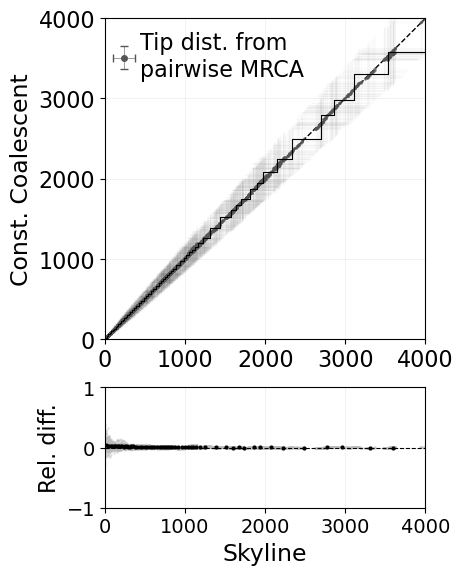

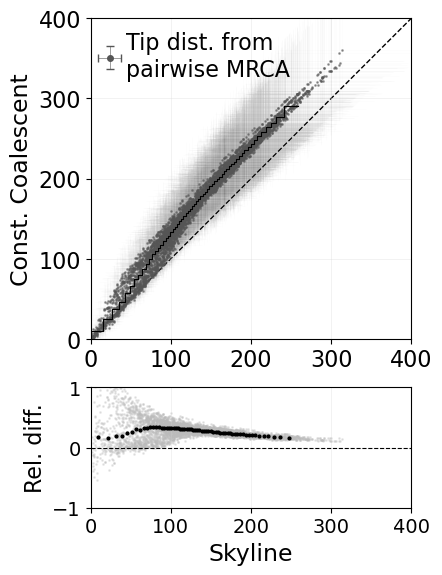

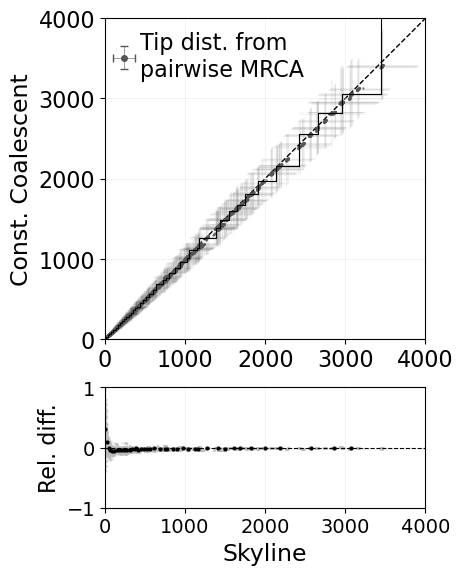

In [4]:
plot_pairwise_tip_distances(uniform_dist_df, sampling="linearconstant", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = 5000,
                            title = "", x_range = (0,4000), y_range = (0,4000),
                            pop_models=['uniform'], mutsigs = ['low'], figsize=(6,4), show_pop_model_labels = False, show_mutsig_labels = False,
                            running_avg=True, running_avg_color = 'black', window_size = 100000, window_overlap = 0,
                            diff_plot = "True", diff_mode = "relative", diff_axis_range = (-1, 1),
                            label_fontsize=17, tick_fontsize=16, legend_fontsize=16,
                            save_path = "../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_uniform_subsampled5000_linearconstant.pdf")

plot_pairwise_tip_distances(expgrowthfast_dist_df, sampling="linearconstant", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = 5000,
                            title = "", x_range = (0, 400), y_range = (0, 400),
                            pop_models=['expgrowthfast'], mutsigs = ['low'], figsize=(6,4), show_pop_model_labels = False, show_mutsig_labels = False,
                            running_avg=True, running_avg_color = 'black', window_size = 100000, window_overlap = 0,
                            diff_plot = "True", diff_mode = "relative", diff_axis_range = (-1,1),
                            label_fontsize=17, tick_fontsize=16, legend_fontsize=16,
                            save_path = "../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_expgrowthfast_subsampled5000_linearconstant.pdf")

plot_pairwise_tip_distances(bottleneck_dist_df, sampling="linearconstant", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = 5000,
                            title = "", x_range = (0, 4000), y_range = (0, 4000),
                            pop_models=['bottleneck'], mutsigs = ['low'], figsize=(6,4), show_pop_model_labels = False, show_mutsig_labels = False,
                            running_avg=True, running_avg_color = 'black', window_size = 100000, window_overlap = 0,
                            diff_plot = "True", diff_mode = "relative", diff_axis_range = (-1,1),
                            label_fontsize=17, tick_fontsize=16, legend_fontsize=16,
                            save_path = "../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_bottleneck_subsampled5000_linearconstant.pdf")


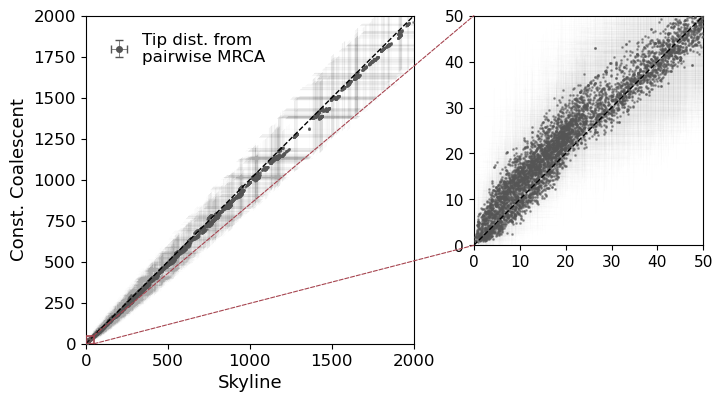

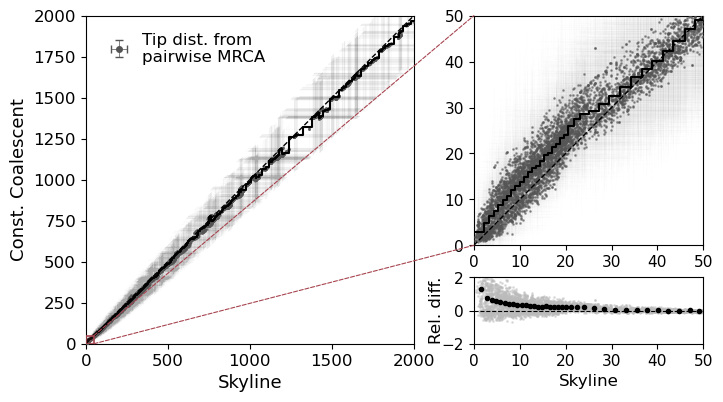

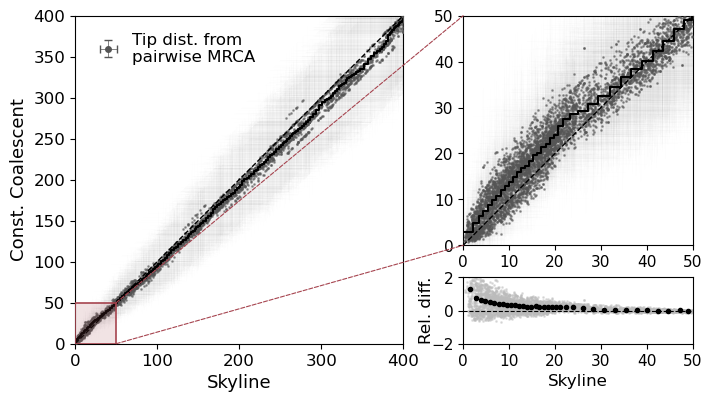

In [5]:
plot_pairwise_tip_distances_zoom(after_bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 2000), y_range=(0, 2000),
      zoom_x_range=(0,50), zoom_y_range=(0, 50),
      figsize=(10, 4), title="", label_fontsize=13, tick_fontsize=12, legend_fontsize=12,
      save_path="../figures/branch_length/pairwise_tip_distance/afterbottleneck_pairwise_tip_distances_bottleneck_zoom_linearconstant.pdf")

plot_pairwise_tip_distances_zoom(after_bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 2000), y_range=(0, 2000),
      zoom_x_range=(0,50), zoom_y_range=(0, 50),
      figsize=(10, 4), title="", label_fontsize=13, tick_fontsize=12, legend_fontsize=12,
      running_avg=True, running_avg_color = 'black', window_size = 10000, window_overlap = 5000, window_size_zoom = 5000, window_overlap_zoom = 0,
      diff_plot = "True", diff_mode = "relative", diff_axis_range = (-2,2),
      save_path="../figures/branch_length/pairwise_tip_distance/afterbottleneck_pairwise_tip_distances_bottleneck_zoom_linearconstant_reldiff.pdf",
      )

plot_pairwise_tip_distances_zoom(after_bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 400), y_range=(0, 400),
      zoom_x_range=(0,50), zoom_y_range=(0, 50),
      figsize=(10, 4), title="",label_fontsize=13, tick_fontsize=12, legend_fontsize=12,
      running_avg=True, running_avg_color = 'black', window_size = 10000, window_overlap = 5000, window_size_zoom = 5000, window_overlap_zoom = 0,
      diff_plot = "True", diff_mode = "relative", diff_axis_range = (-2,2),
      save_path="../figures/branch_length/pairwise_tip_distance/afterbottleneck_pairwise_tip_distances_bottleneck_zoom_linearconstant_reldiff_small.pdf",
      )

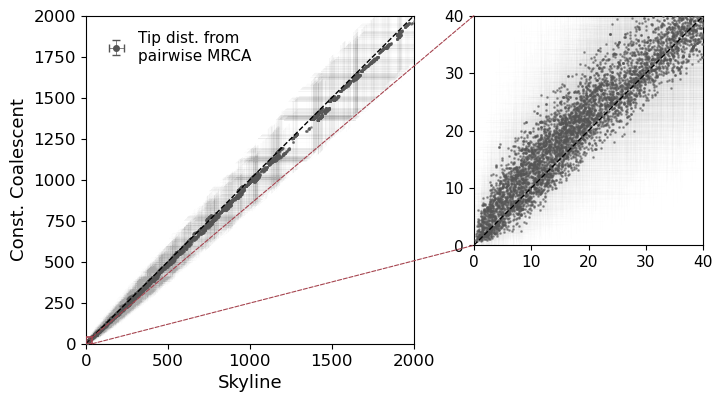

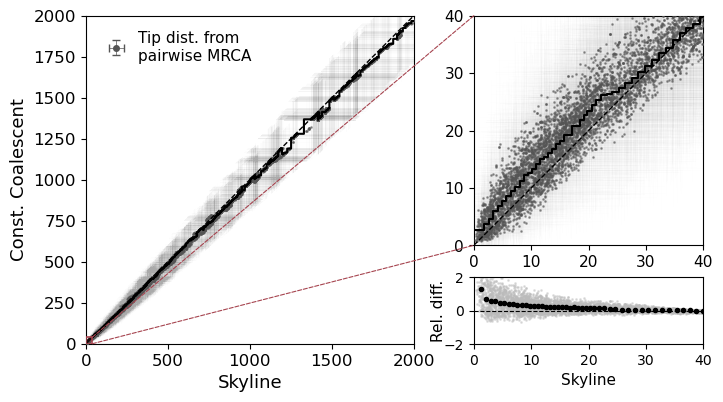

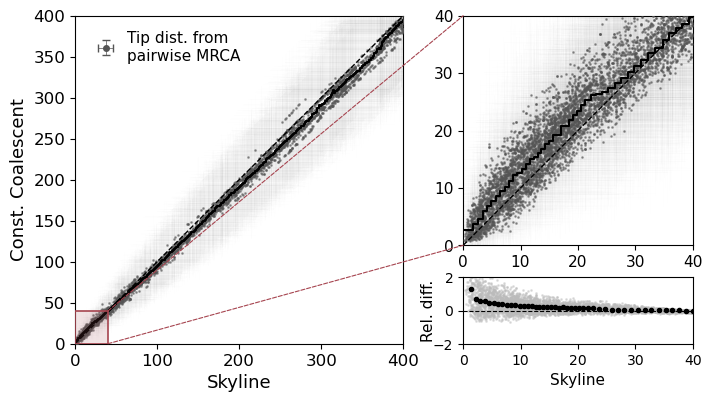

In [12]:
plot_pairwise_tip_distances_zoom(bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 2000), y_range=(0, 2000),
      zoom_x_range=(0,40), zoom_y_range=(0, 40),
      figsize=(10, 4), title="",
      save_path="../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_bottleneck_zoom_linearconstant.pdf")

plot_pairwise_tip_distances_zoom(bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 2000), y_range=(0, 2000),
      zoom_x_range=(0,40), zoom_y_range=(0, 40),
      figsize=(10, 4), title="",
      running_avg=True, running_avg_color = 'black', window_size = 10000, window_overlap = 5000, window_size_zoom = 5000, window_overlap_zoom = 0,
      diff_plot = "True", diff_mode = "relative", diff_axis_range = (-2,2),
      save_path="../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_bottleneck_zoom_linearconstant_reldiff.pdf",
      )

plot_pairwise_tip_distances_zoom(bottleneck_dist_df, sampling="linearconstant",
      alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample=10000, n_subsample_zoom=5000,
      pop_model="bottleneck", mutsig="low",
      x_range=(0, 400), y_range=(0, 400),
      zoom_x_range=(0,40), zoom_y_range=(0, 40),
      figsize=(10, 4), title="",
      running_avg=True, running_avg_color = 'black', window_size = 10000, window_overlap = 5000, window_size_zoom = 5000, window_overlap_zoom = 0,
      diff_plot = "True", diff_mode = "relative", diff_axis_range = (-2,2),
      save_path="../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_bottleneck_zoom_linearconstant_reldiff_small.pdf",
      )

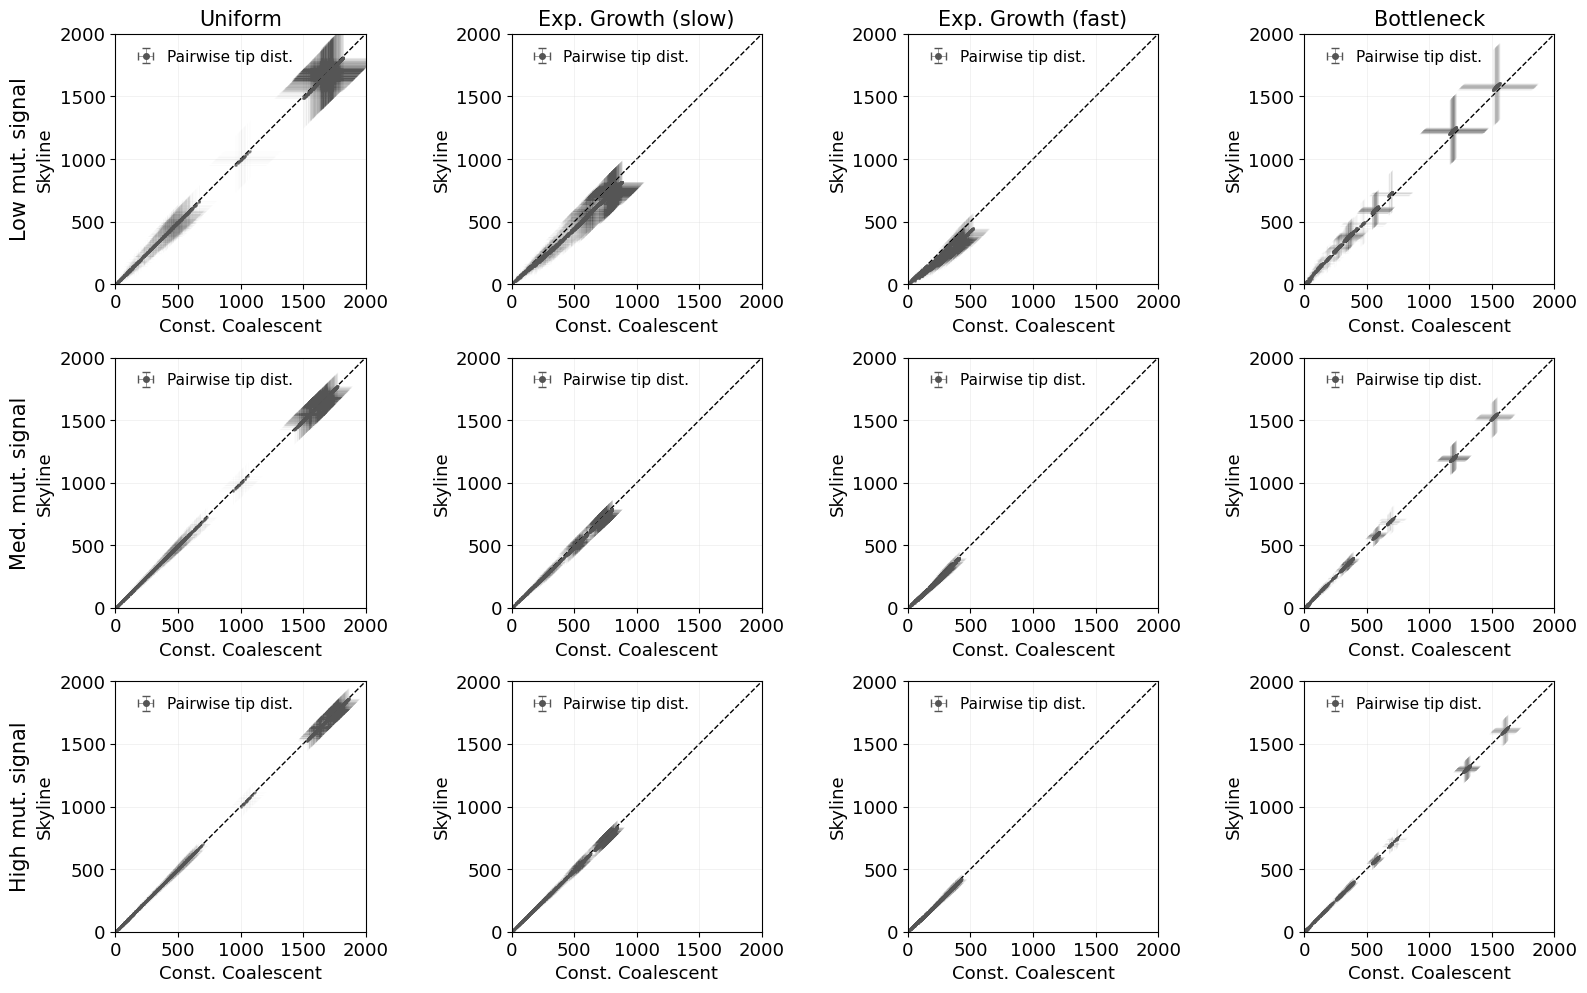

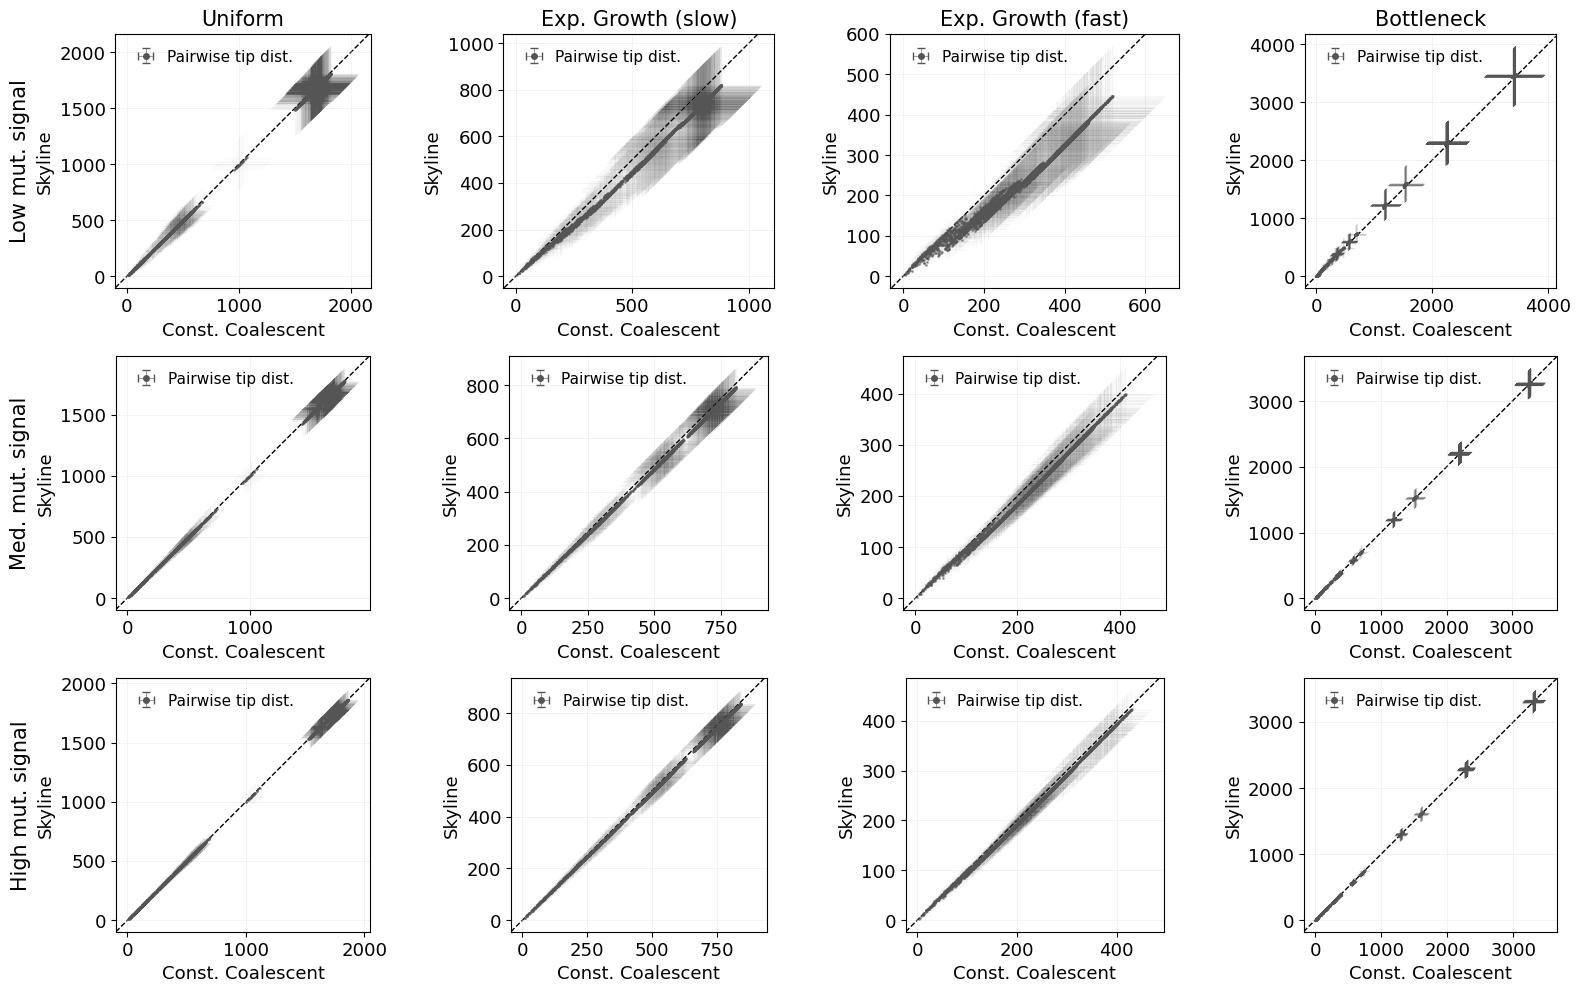

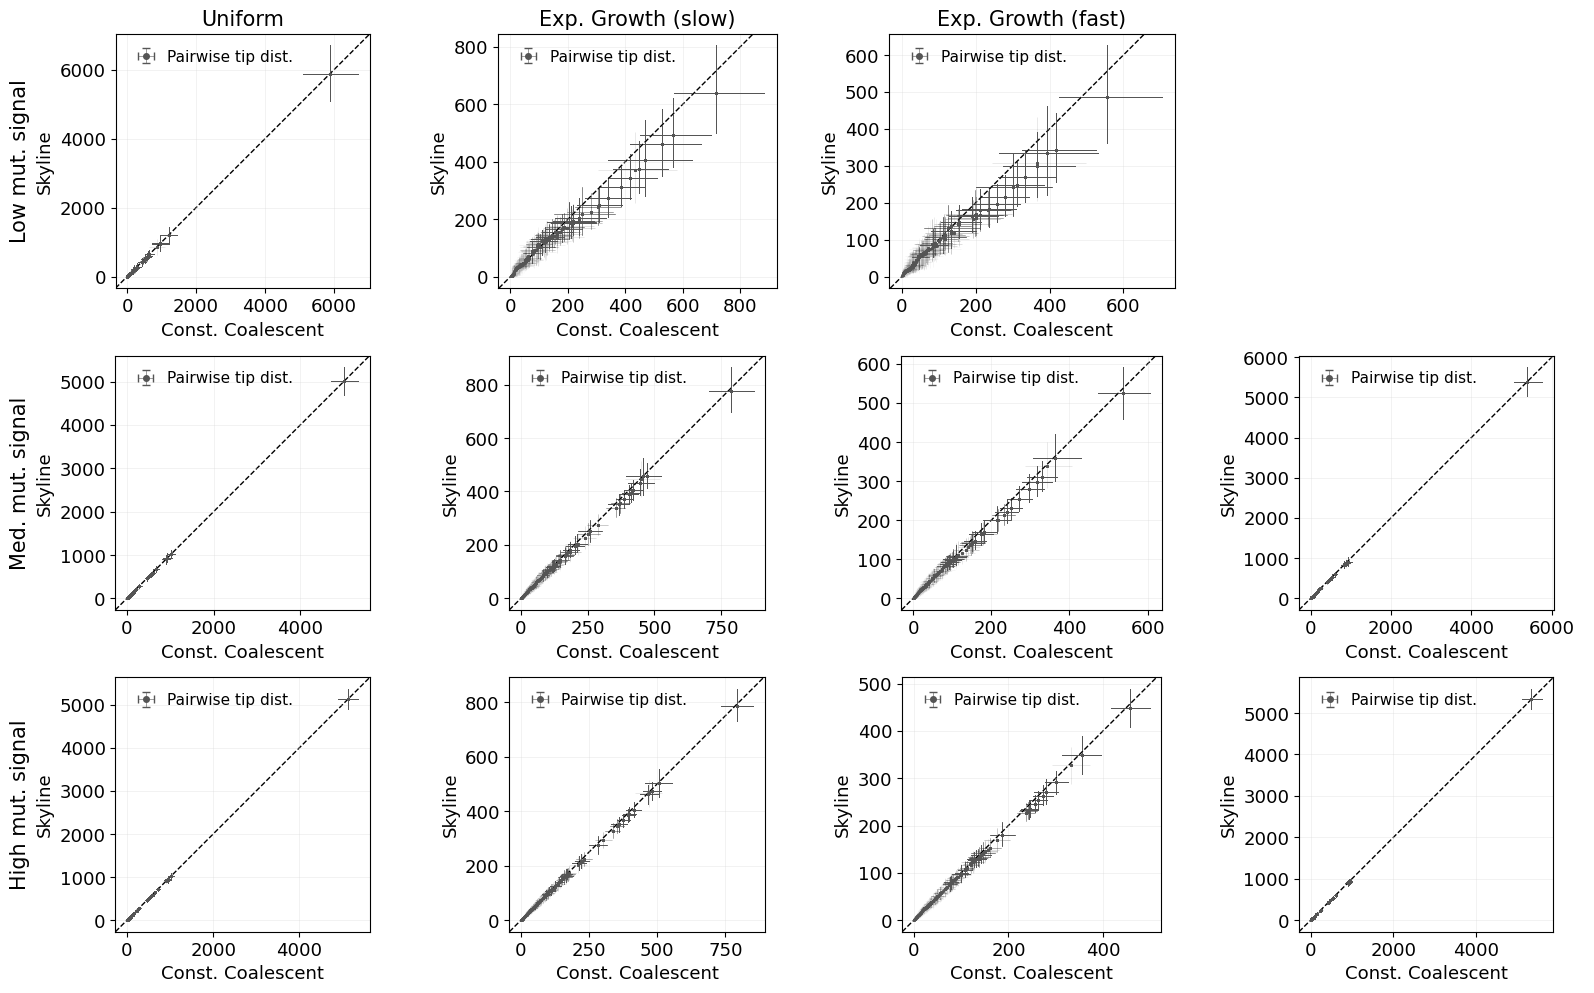

In [19]:
plot_pairwise_tip_distances(dist_df, sampling="linearconstant", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = 5000, title = "", x_range = (0,2000), y_range = (0,2000))
plot_pairwise_tip_distances(dist_df, sampling="linearconstant", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = 5000, title = "", x_range = None, y_range = None, save_path = "../figures/branch_length/pairwise_tip_distance/pairwise_tip_distances_all_subsampled5000_linearconstant.pdf")
plot_pairwise_tip_distances(dist_df, sampling="independenthomochronous", alpha=0.5, errorbar_alpha=0.01, errorbar_width=0.5, n_subsample = None, title = "", x_range = None, y_range = None)

## HPD Coverage

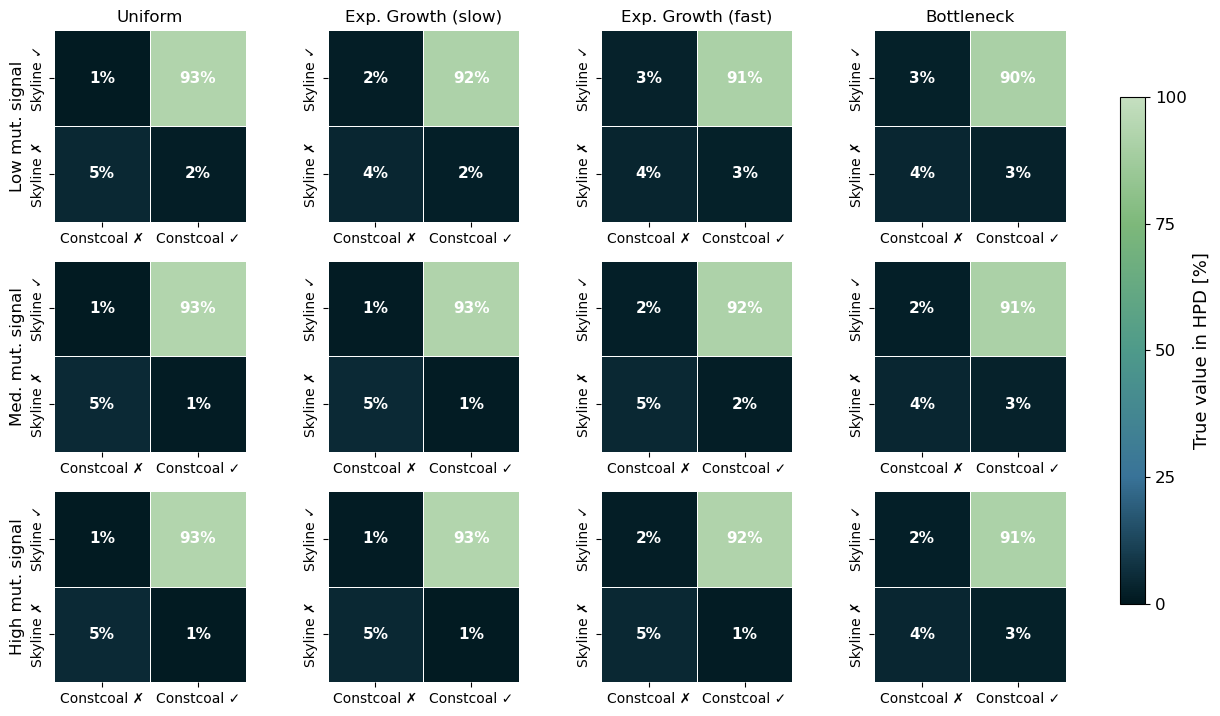

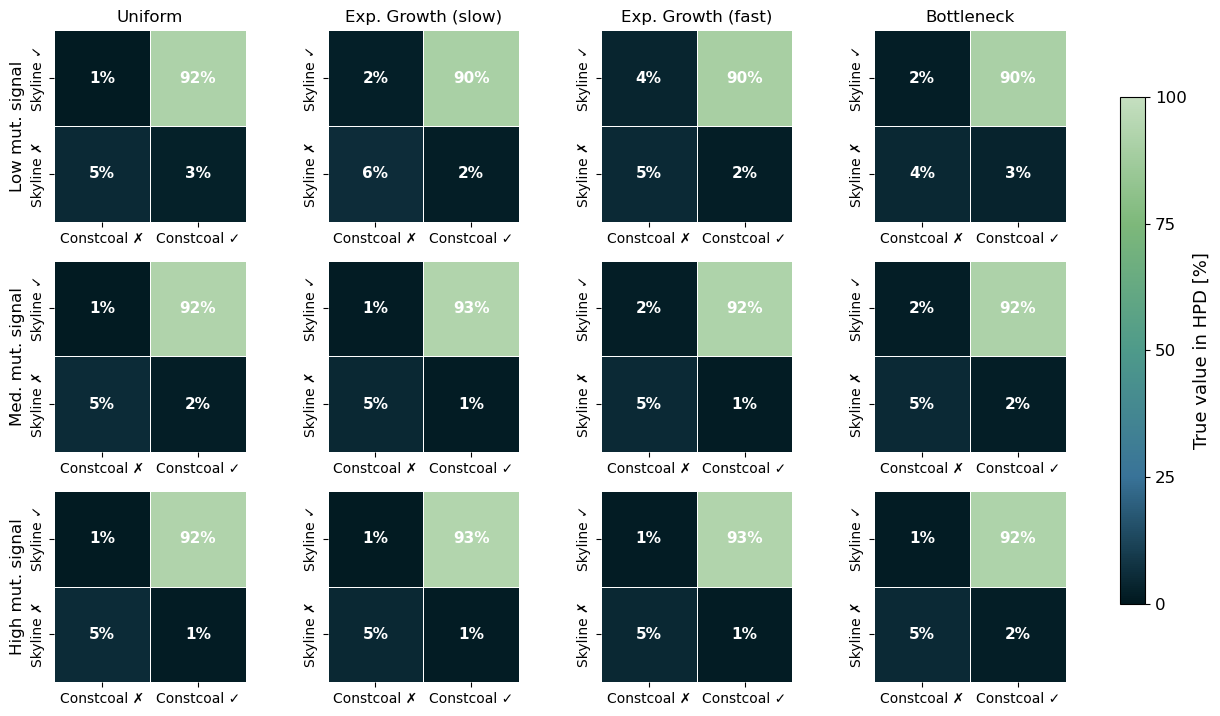

In [4]:
plot_ci_coverage_heatmap_nodes(tree_metrics_combined, mode="bl", sampling='linearconstant', title = "", save_path= "../figures/branch_length/coverage_heatmaps/hpd_coverage_heatmap_bl_linearconstant.pdf", cbar_label = "True value in HPD [%]")
plot_ci_coverage_heatmap_nodes(tree_metrics_combined, mode="bl", sampling='independenthomochronous', title = "", save_path= "../figures/branch_length/coverage_heatmaps/hpd_coverage_heatmap_bl_independenthomochronous.pdf", cbar_label = "True value in HPD [%]")

## Branch length error with population development

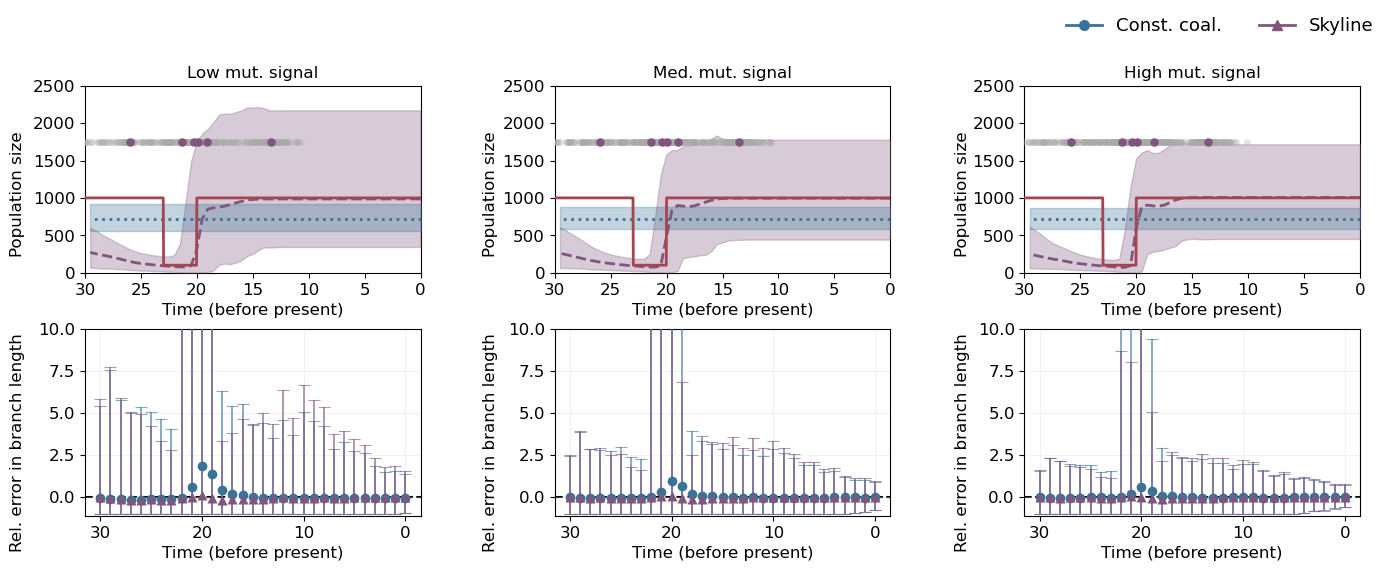

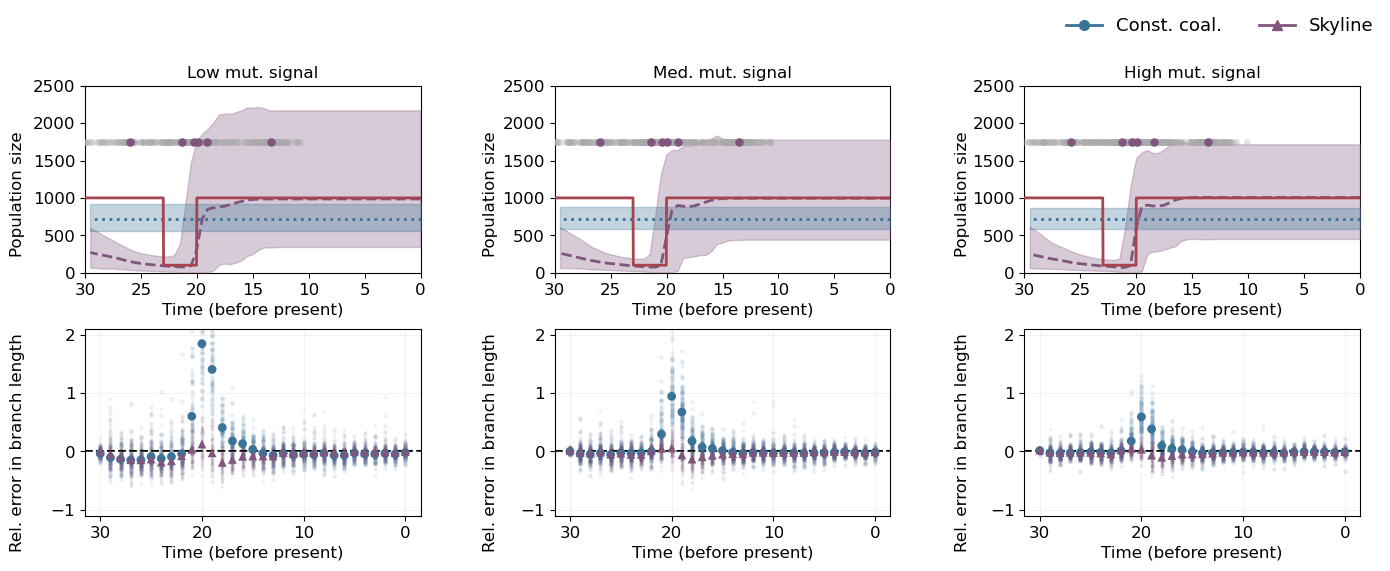

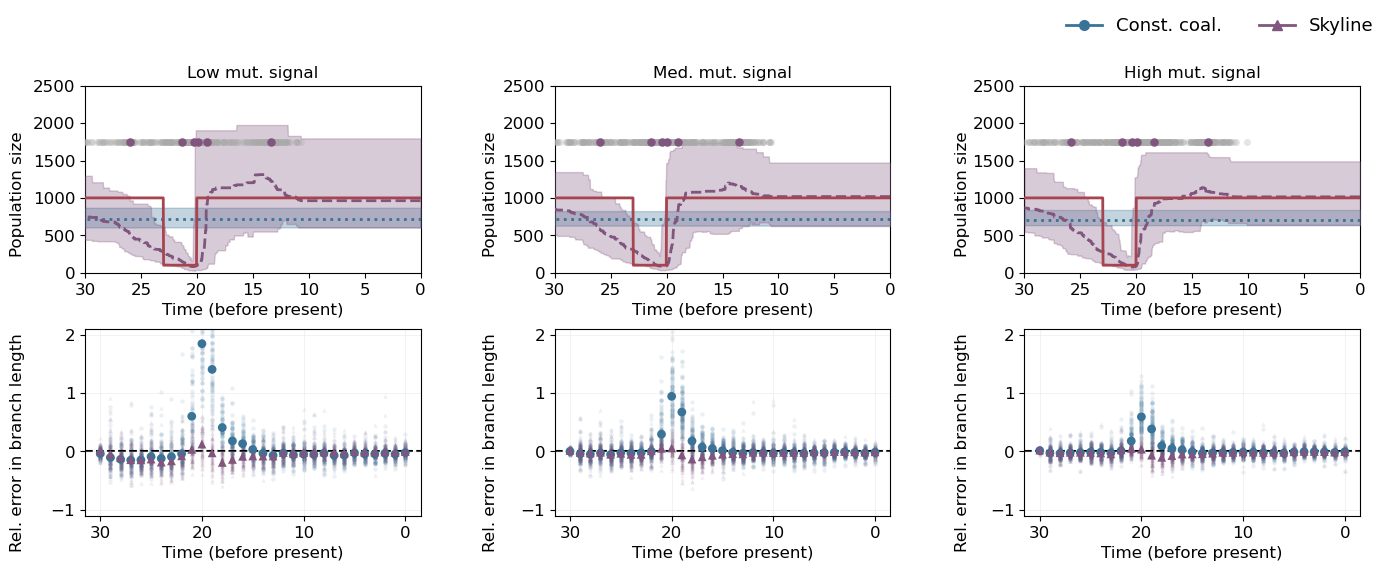

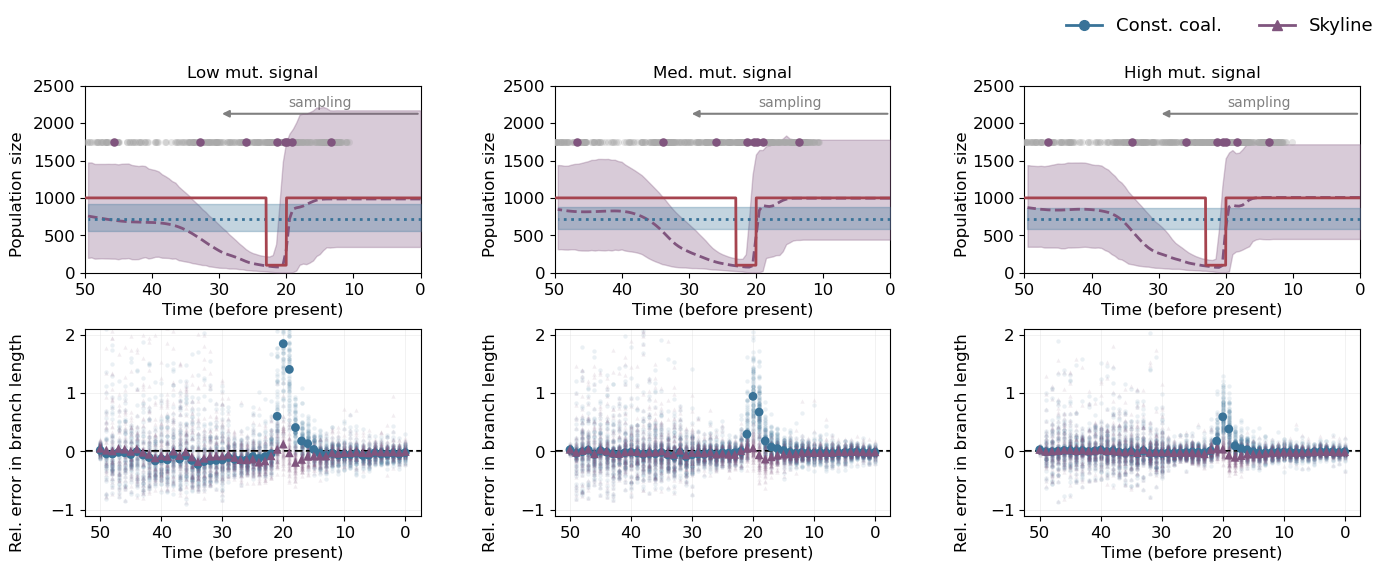

In [8]:
plot_combined_population_and_error(
      df_population=df_pop_info, trajectory_df = traj_df,
      df_time_bins=df_1_30,   # from load_time_bins(eval_dir, bin_width=10, cutoff=100)
      sampling="linearconstant",
      error_col="bl_rel_error_median",
      pop_y_range=(0, 2500),
      error_y_range=(-1.1,10),
      min_nodes_per_bin = 20, time_col = "bin_lower",
      title="", x_label = "Time (before present)", error_y_label = "Rel. error in branch length",
      errorbar_alpha = 0.6, jitter_width = 0, marker_edgecolor='none',
      save_path="../figures/branch_length/time_overview/bottleneck_blerror_popsize_linearconstant_wide.pdf",
      ylabel_x_positions=[0.075, 0.39, 0.705], error_ylabel_y_offset=-0.06,
  )

plot_combined_population_and_error(
      df_population=df_pop_info, trajectory_df = traj_df,
      df_time_bins=df_1_30,   # from load_time_bins(eval_dir, bin_width=10, cutoff=100)
      sampling="linearconstant",
      error_col="bl_rel_error_median",
      pop_y_range=(0, 2500),
      error_y_range=(-1.1,2.1),
      min_nodes_per_bin = 20, time_col = "bin_lower",
      title="", x_label = "Time (before present)", error_y_label = "Rel. error in branch length",
      per_tree_df=df_1_30_pertree, raw_alpha = 0.1, errorbar_alpha = 0, jitter_width = 0, marker_edgecolor='none',
      save_path="../figures/branch_length/time_overview/bottleneck_blerror_popsize_linearconstant_small.pdf",
      ylabel_x_positions=[0.075, 0.39, 0.705], error_ylabel_y_offset=-0.06,
  )

plot_combined_population_and_error(
      df_population=df_pop_info,
      df_time_bins=df_1_30,   # from load_time_bins(eval_dir, bin_width=10, cutoff=100)
      sampling="linearconstant",
      error_col="bl_rel_error_median",
      pop_y_range=(0, 2500),
      error_y_range=(-1.1,2.1),
      min_nodes_per_bin = 20, time_col = "bin_lower",
      title="", x_label = "Time (before present)", error_y_label = "Rel. error in branch length",
      per_tree_df=df_1_30_pertree, raw_alpha = 0.1, errorbar_alpha = 0, jitter_width = 0, marker_edgecolor='none',
      save_path="../figures/branch_length/time_overview/bottleneck_blerror_popsize_linearconstant_small_notrajectory.pdf",
      ylabel_x_positions=[0.075, 0.39, 0.705], error_ylabel_y_offset=-0.06,
  )


plot_combined_population_and_error(
      df_population=df_pop_info, trajectory_df = traj_df,
      df_time_bins=df_1_50,   # from load_time_bins(eval_dir, bin_width=10, cutoff=100)
      sampling="linearconstant",
      error_col="bl_rel_error_median",
      pop_y_range=(0, 2500),
      error_y_range=(-1.1,2.1),
      min_nodes_per_bin = 20, time_col = "bin_lower",
      title="", x_label = "Time (before present)", error_y_label = "Rel. error in branch length",
      per_tree_df=df_1_50_pertree, raw_alpha = 0.1, errorbar_alpha = 0, jitter_width = 0, marker_edgecolor='none',
      save_path="../figures/branch_length/time_overview/bottleneck_blerror_popsize_linearconstant_small_50.pdf",
      ylabel_x_positions=[0.075, 0.39, 0.705], error_ylabel_y_offset=-0.06,
      sampling_end_time=30,
  )

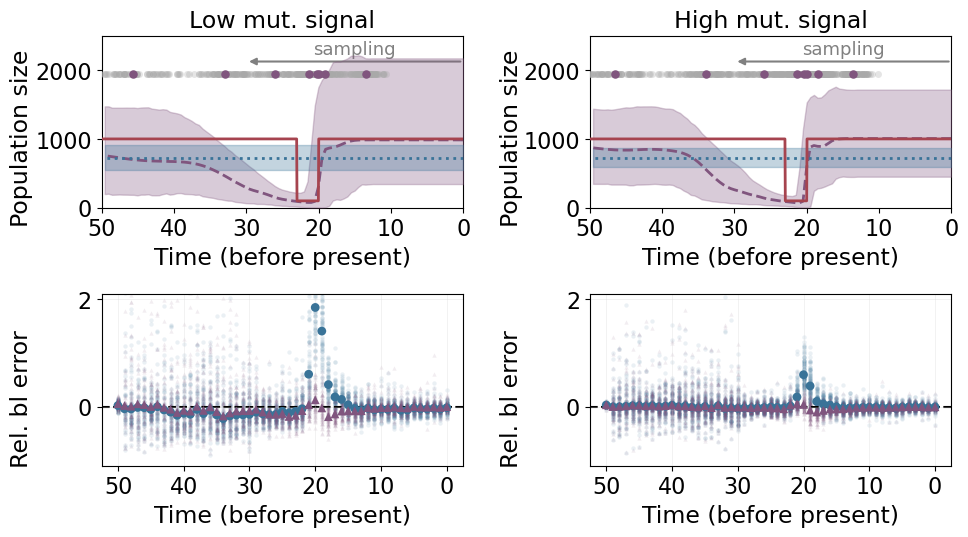

In [ ]:
plot_combined_population_and_error(
      df_population=df_pop_info, trajectory_df = traj_df,
      df_time_bins=df_1_50,   # from load_time_bins(eval_dir, bin_width=10, cutoff=100)
      sampling="linearconstant",
      error_col="bl_rel_error_median",
      mutsigs = ['low', 'high'],
      pop_y_range=(0, 2500),
      error_y_range=(-1.1,2.1),
      min_nodes_per_bin = 20, time_col = "bin_lower",
      title="", x_label = "Time (before present)", error_y_label = "Rel. bl error",
      per_tree_df=df_1_50_pertree, raw_alpha = 0.1, errorbar_alpha = 0, jitter_width = 0, marker_edgecolor='none',
      save_path="../figures/branch_length/time_overview/bottleneck_blerror_popsize_linearconstant_small_50_lowhigh.pdf",
      ylabel_x_positions=[0.04, 0.53], error_ylabel_y_offset=-0.06,
      sampling_end_time=30,
      label_fontsize=17, tick_fontsize=16, legend_fontsize=17, sampling_fontsize=13, hspace = 0.5, wspace = 0.35, xticks = [0, 10, 20, 30, 40, 50], show_legend = False,
      show_changepoints=True, changepoint_dot_size=25, changepoint_grey_alpha=0.3, changepoint_y_frac = 0.78,
  )

## Branch length error over population size and time

- linearconstant
    - only recent time points (closer to present end of time points < 100)
        - rel rate error
            - full range of error bars,
            - meaningful center
        - rel abs rate error
            - meaningful center
        - rel pop size
            - meaningful center
        - rel abs pop size
            - meaningful center
    - all time points (closer to present end of time points < 400)
        - rate
            - meaningful center
        - pop size
            - meaningful center
- independenthomochronous
    - only recent time points (closer to present end of time points < 100)
        - rel rate error
            - meaningful center
        - rel abs rate error
            - meaningful center
        - rel pop size
            - meaningful center
    - all time points (closer to present end of time points < 400)
        - rate
            - meaningful center

Observations:
- nice increase for 1/N error in the last 100 years
- while for relative error, errors cancel each other out around 0, for absolute error the error keeps increasing through time (interesting)
- if closer to root more uncertainty and errors
- independent homochronous shows more or less the same effect but less strong

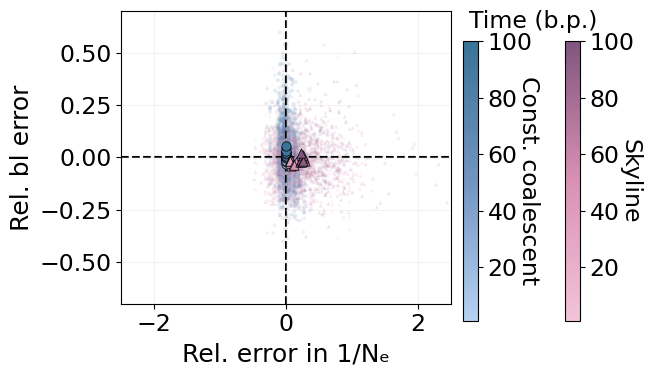

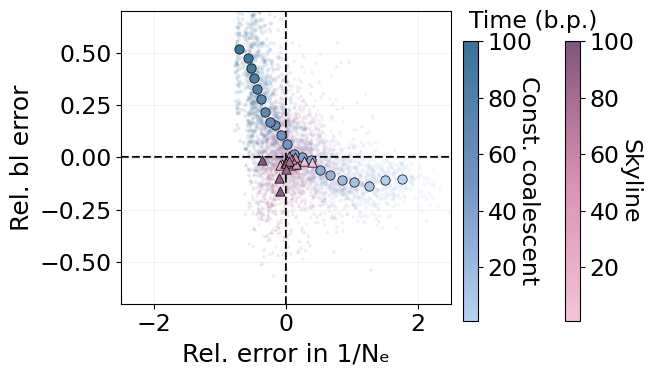

In [3]:
plot_binned_error_timecoloring(df_5_100, per_tree_df = df_50_100_pertree, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(-0.7, 0.7), figsize=(6,4),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. bl error", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform'], mutsigs=['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                               label_fontsize=18, tick_fontsize=17, legend_fontsize=17, cbar_tick_fontsize = 17,
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_pertreeuncertainty_uniform.pdf")

plot_binned_error_timecoloring(df_5_100, per_tree_df = df_50_100_pertree, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(-0.7, 0.7), figsize = (6,4),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. bl error", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['expgrowthfast'], mutsigs=['low'], show_pop_model_labels = False, show_mutsig_labels = False,
                               label_fontsize=18, tick_fontsize=17, legend_fontsize=17, cbar_tick_fontsize = 17,
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_pertreeuncertainty_expgrowthfast.pdf")

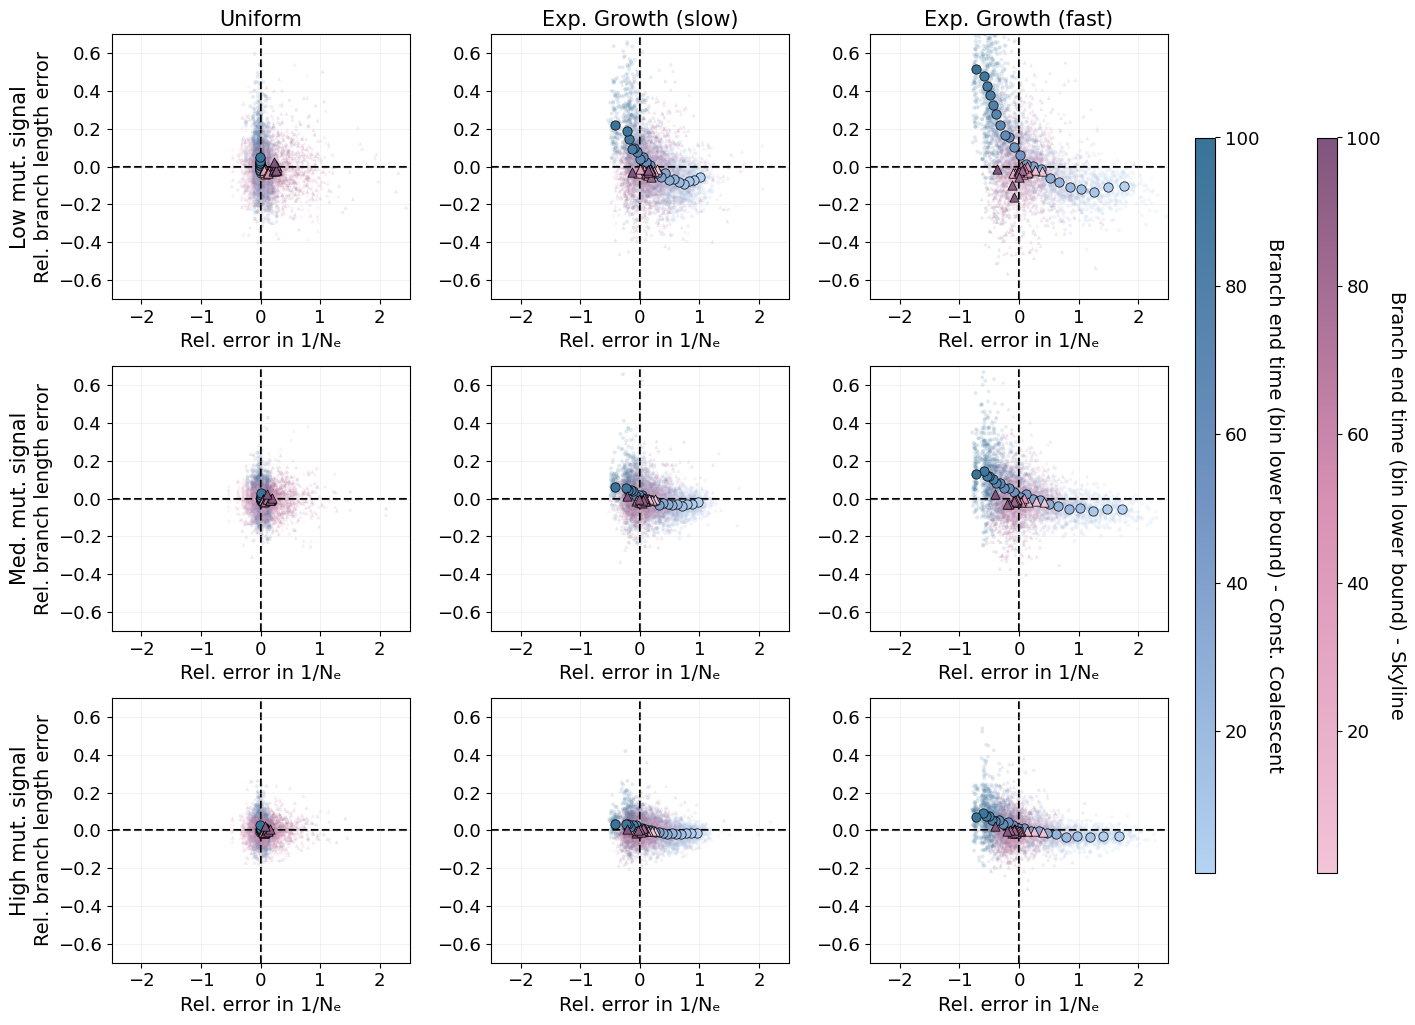

In [6]:
plot_binned_error_timecoloring(df_5_100, per_tree_df = df_50_100_pertree, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(-0.7, 0.7),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. branch length error", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_pertreeuncertainty.pdf")

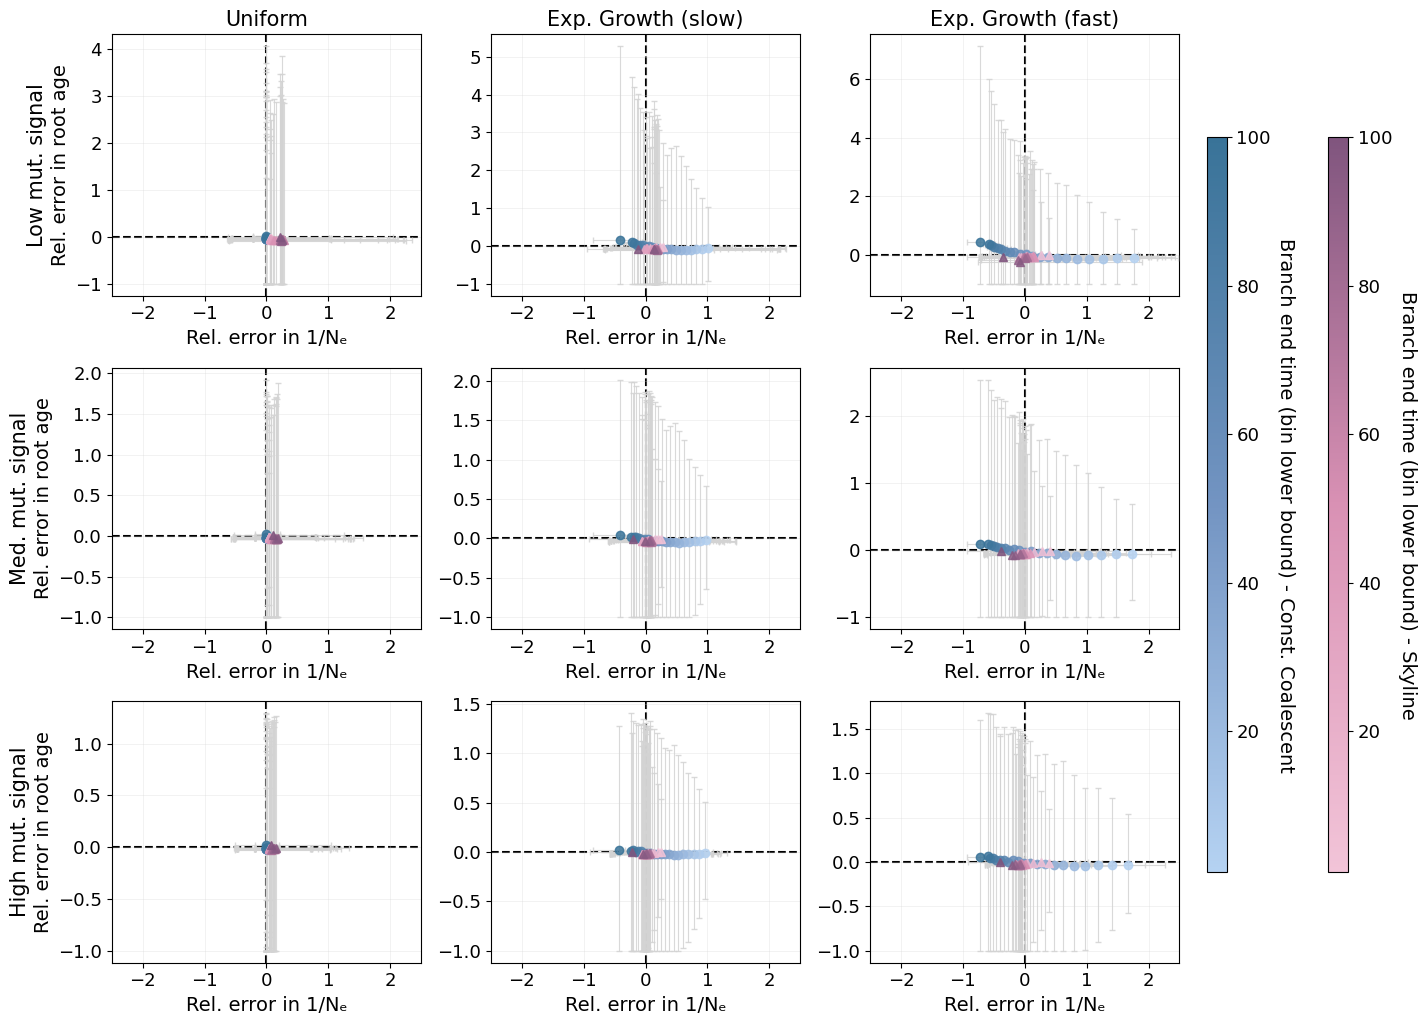

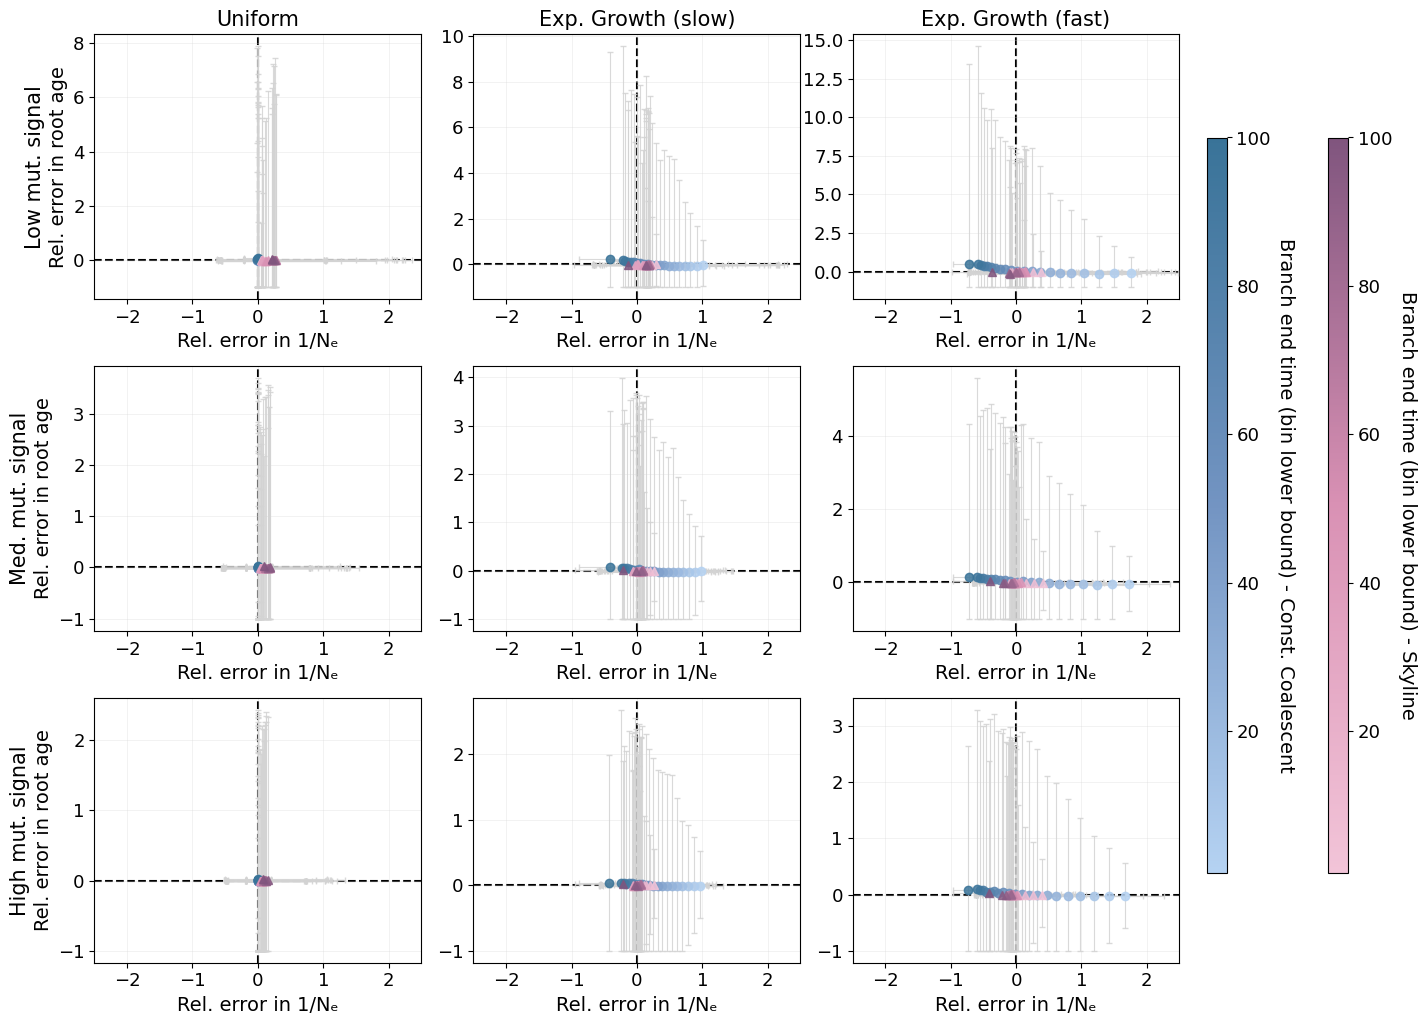

In [7]:
# linearconstant

## bin length 5, last bin at 100
### rate (rel error)
plot_binned_error_timecoloring(df_5_100_longbl, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=None,
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path=None)

plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=None,
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path=None)

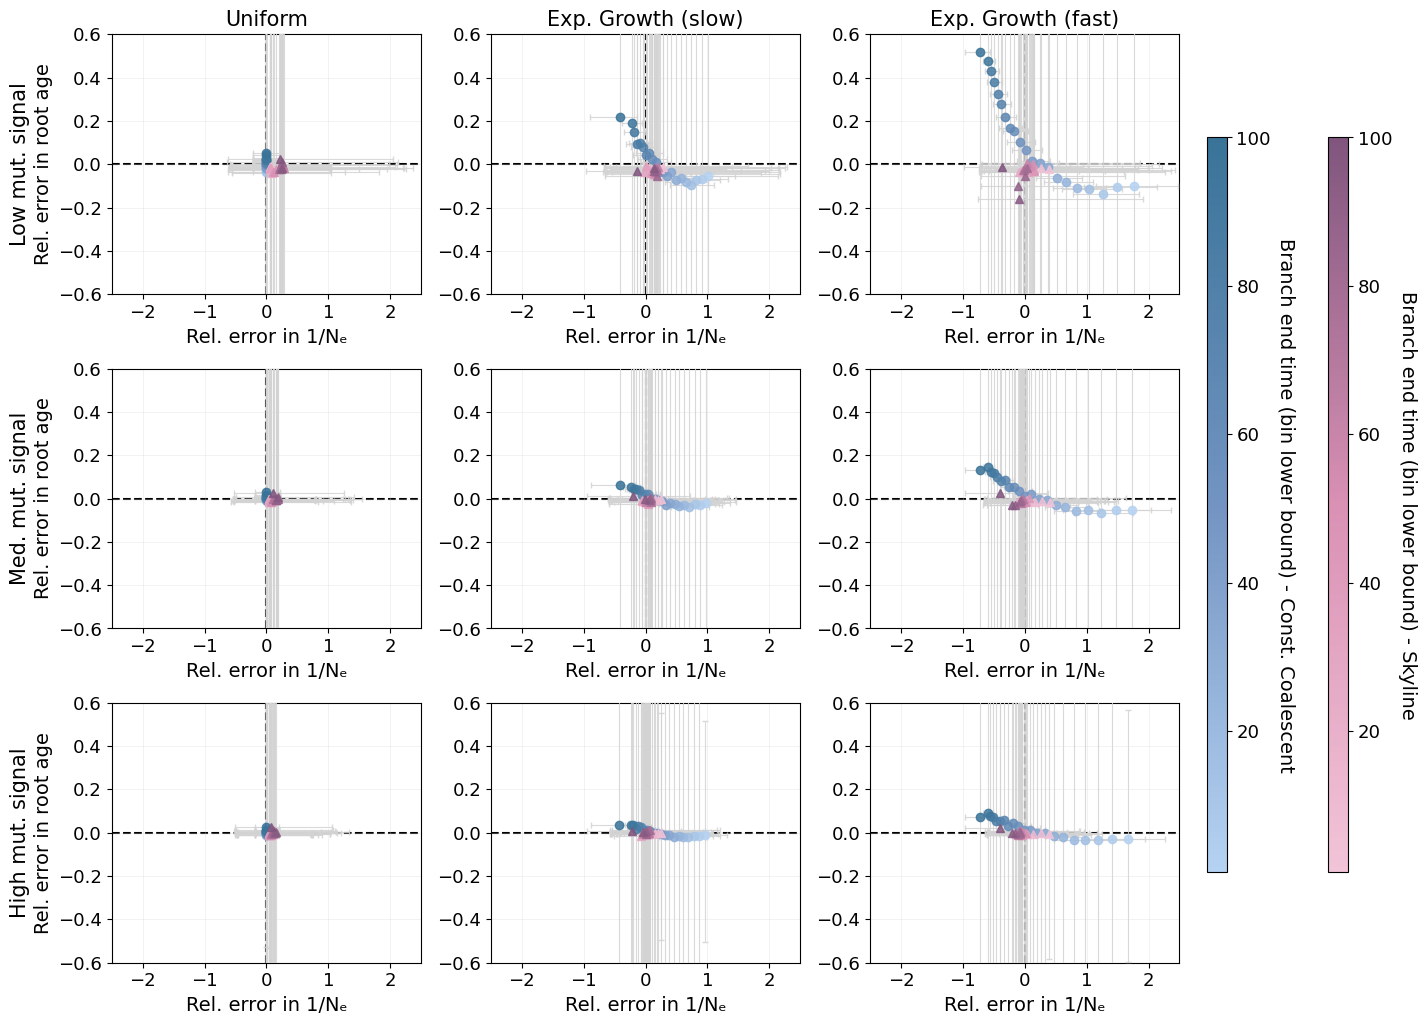

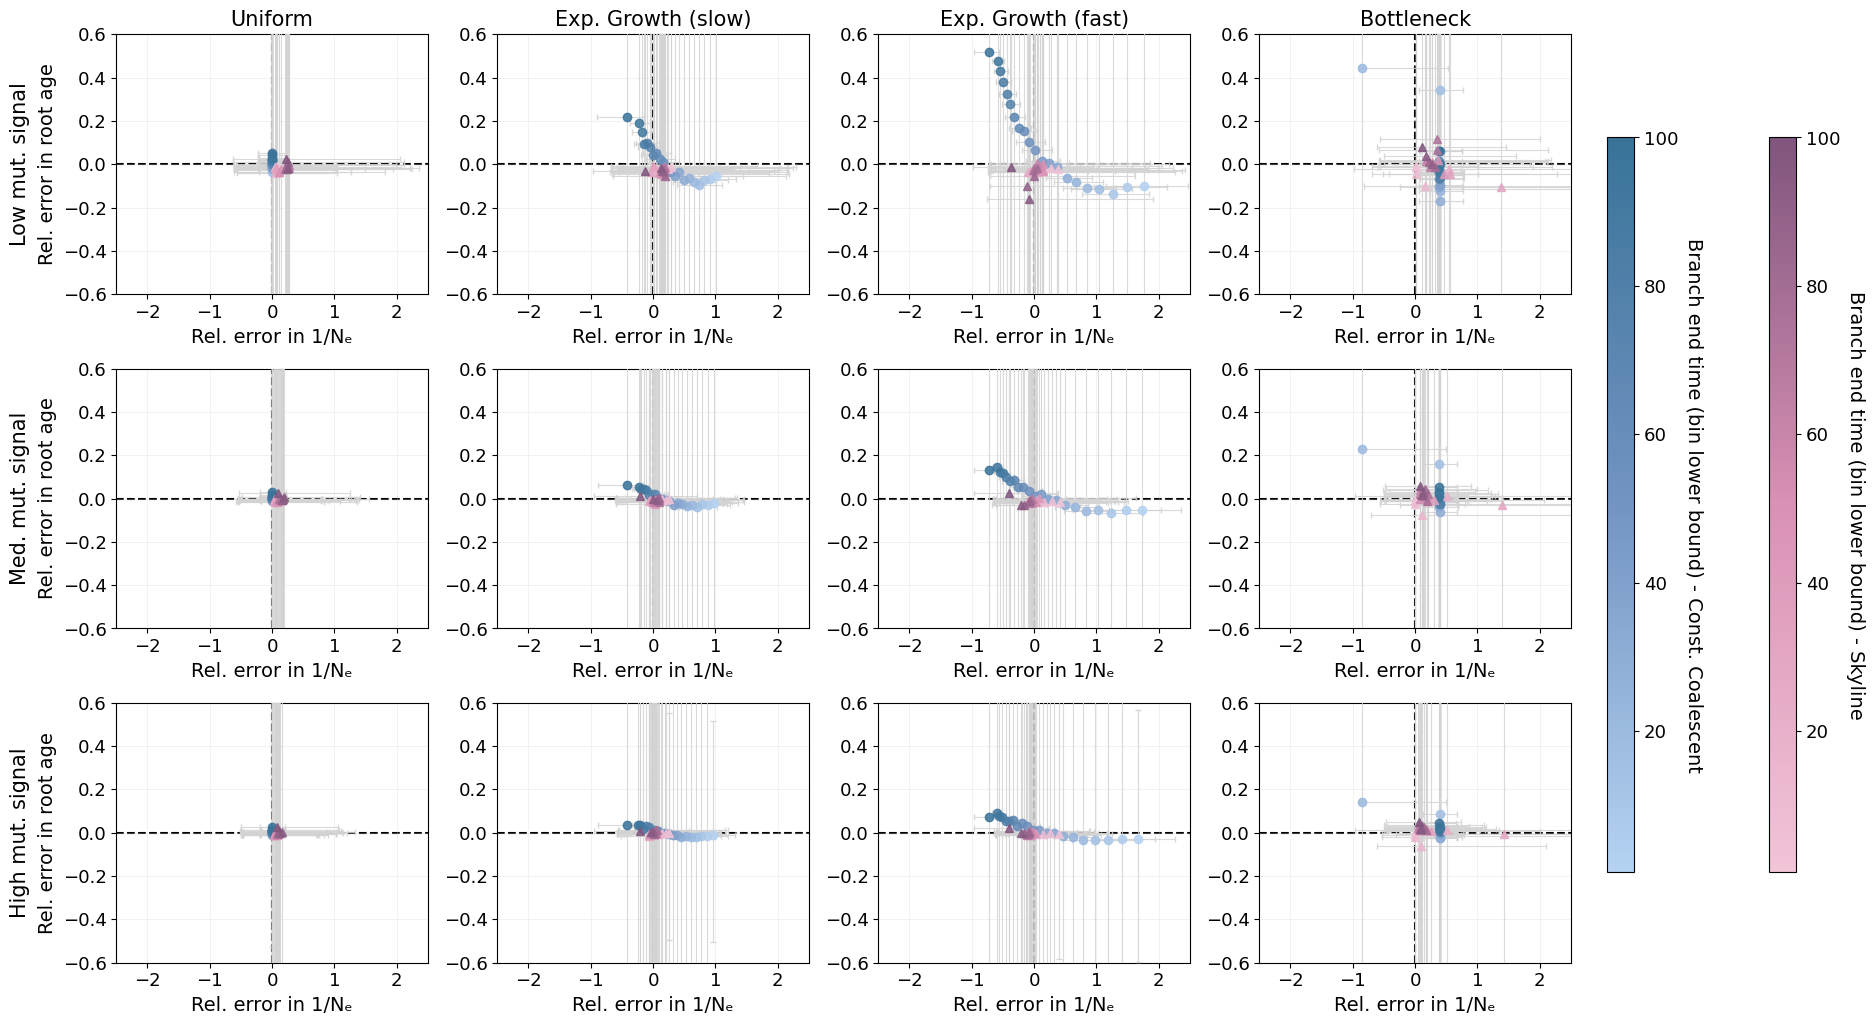

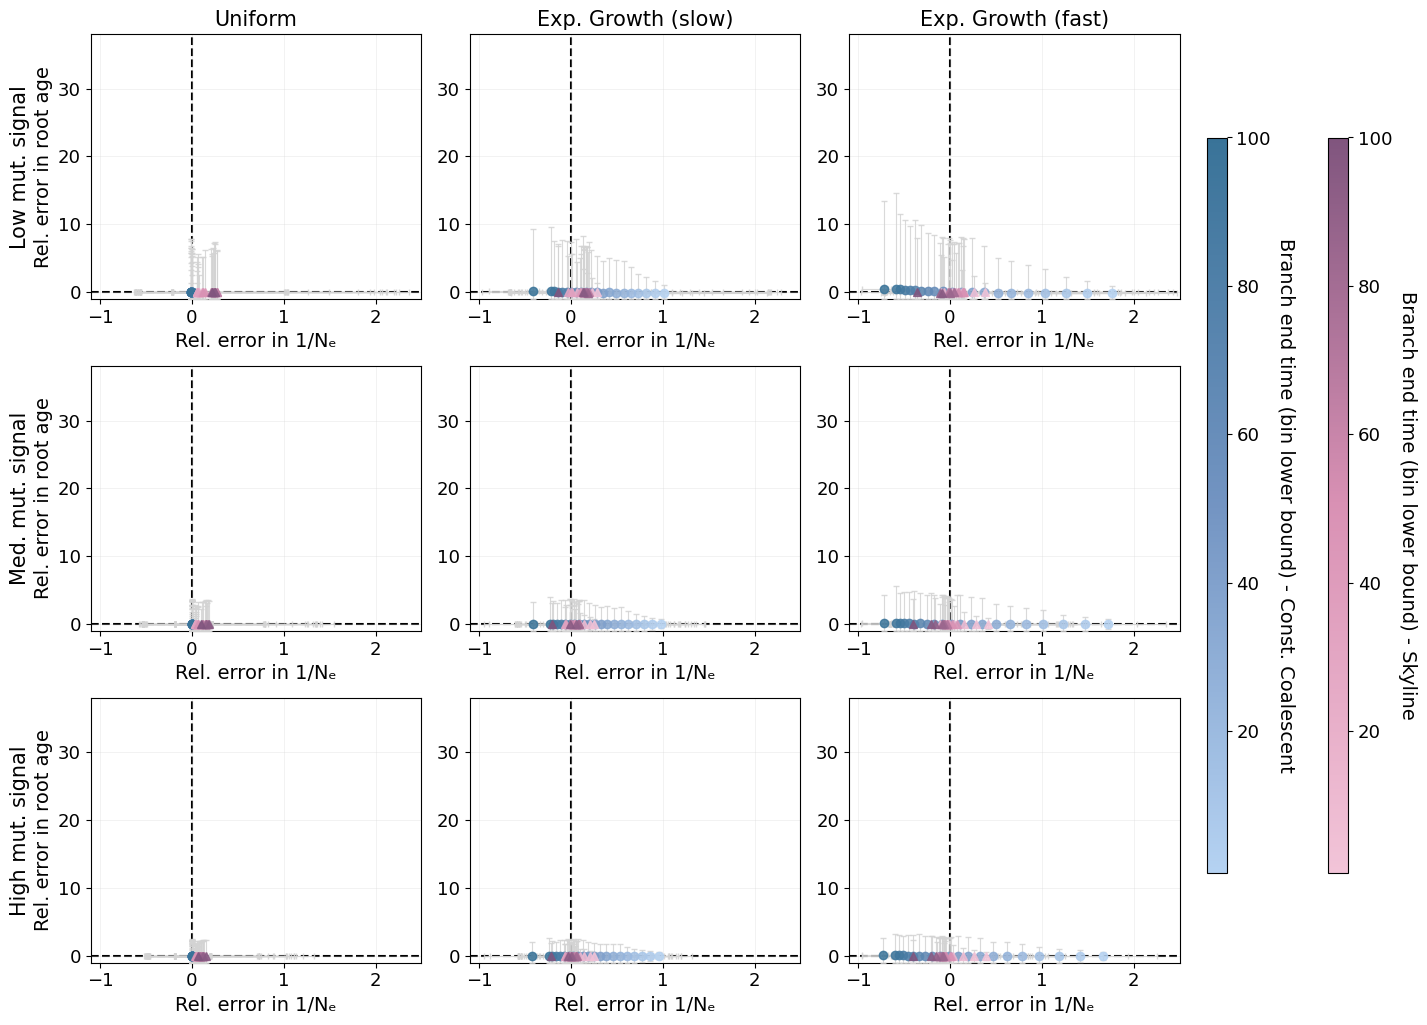

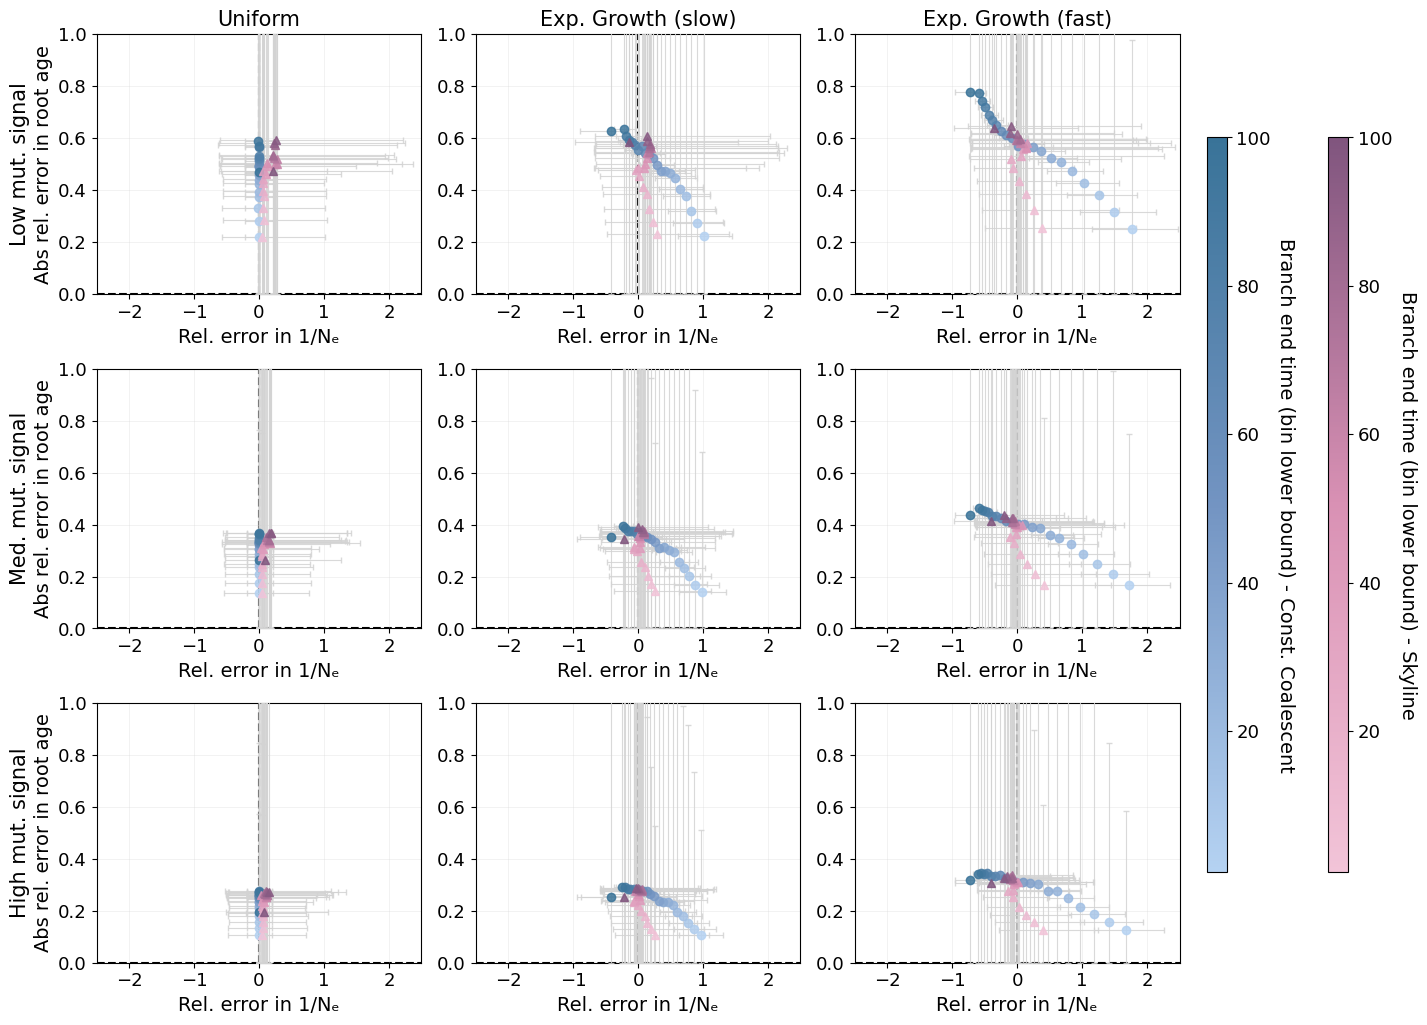

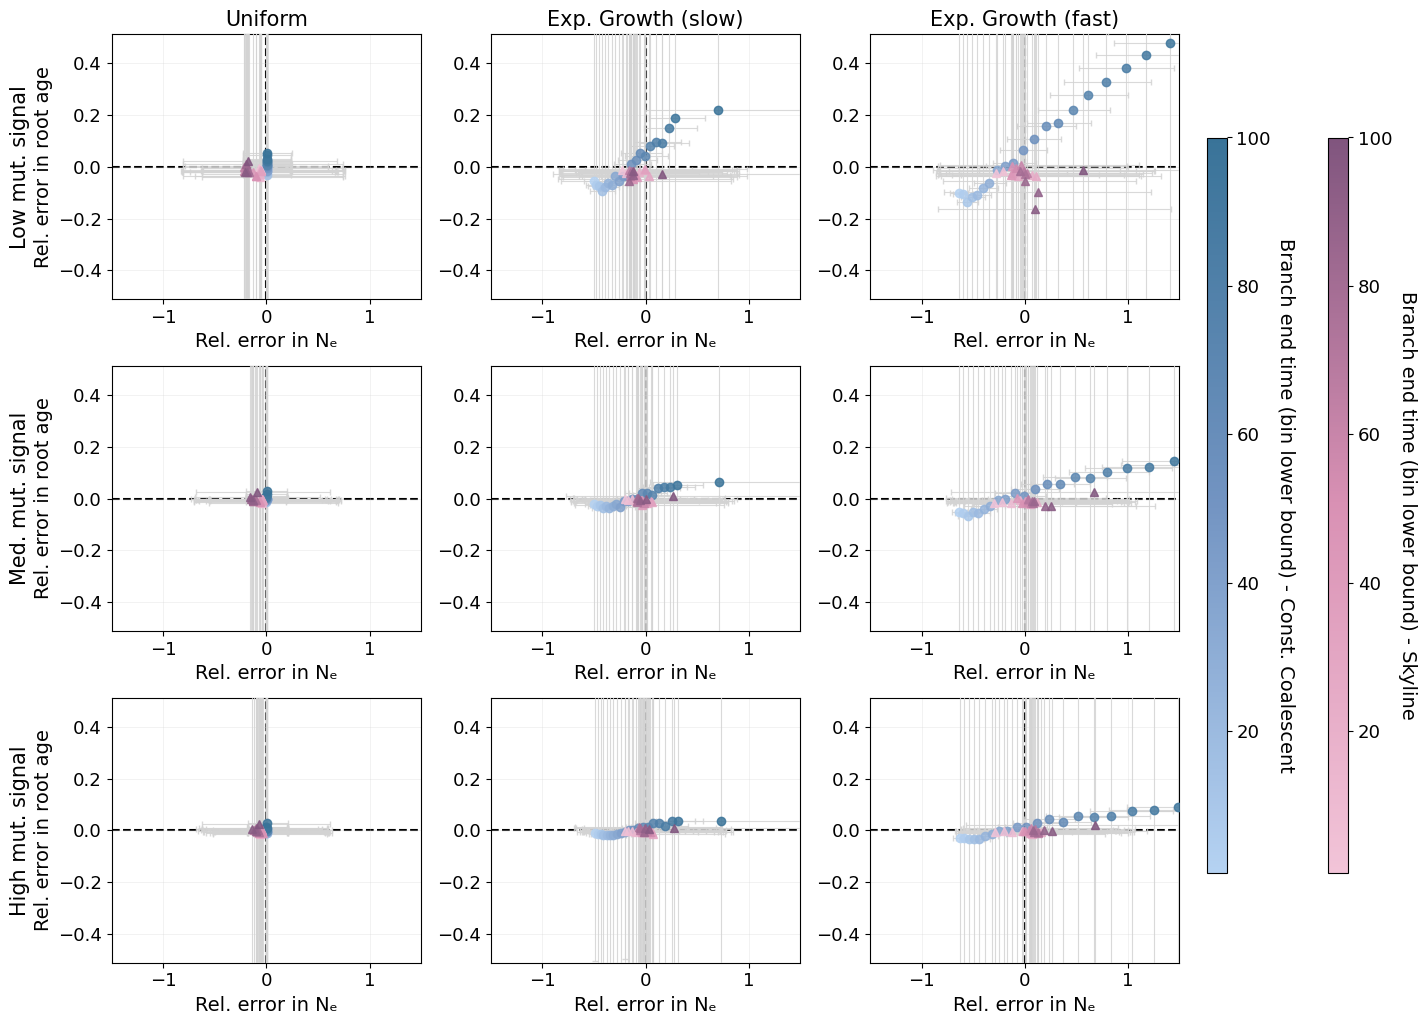

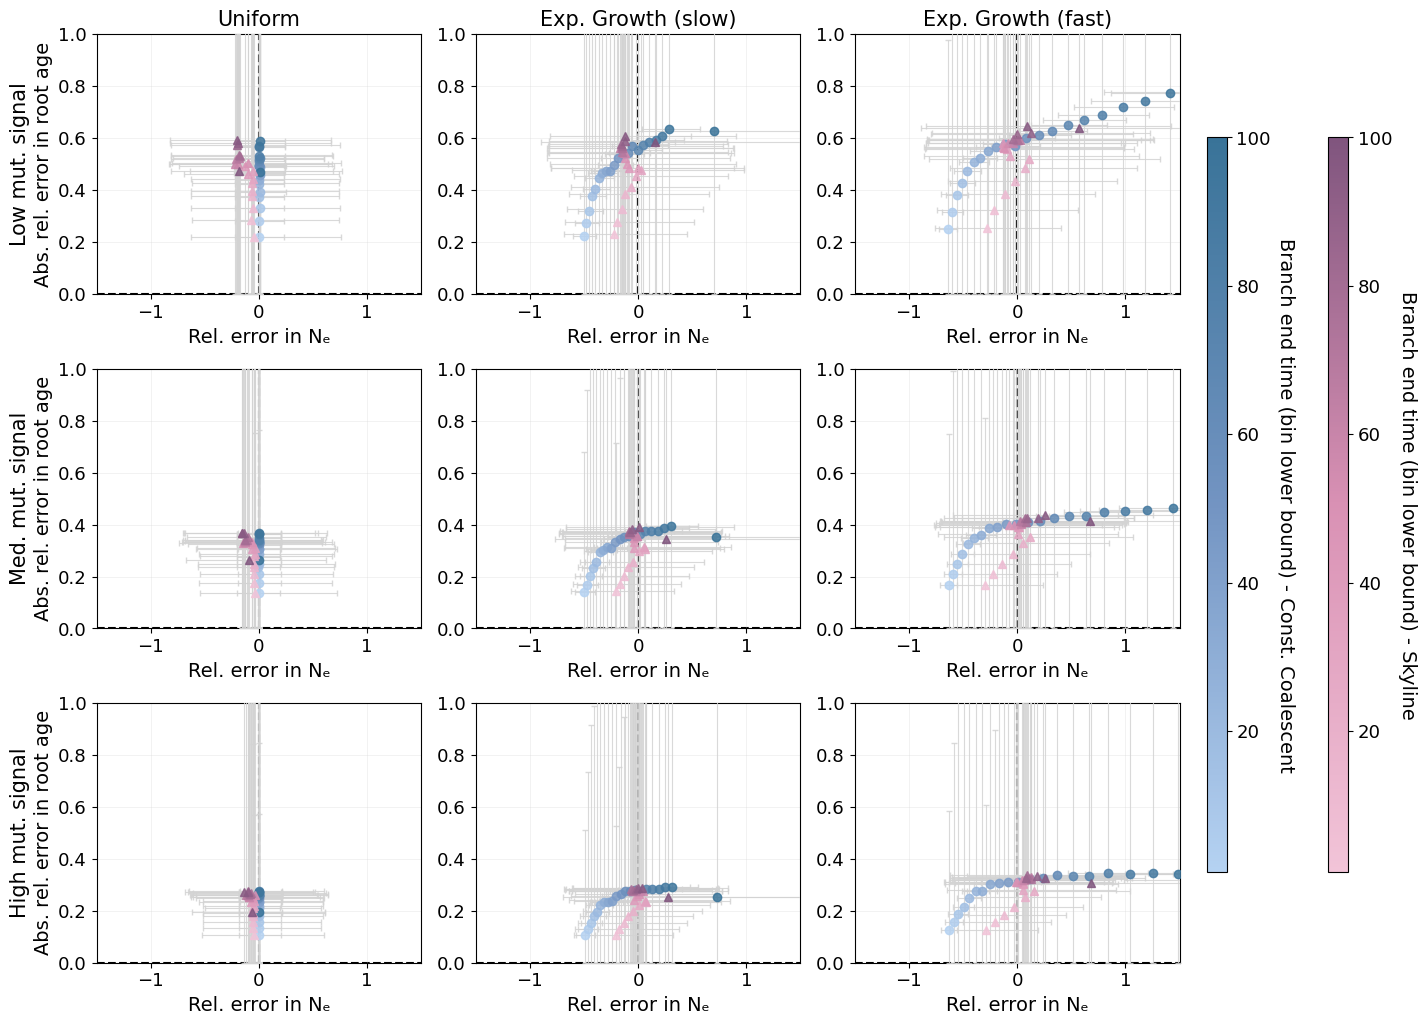

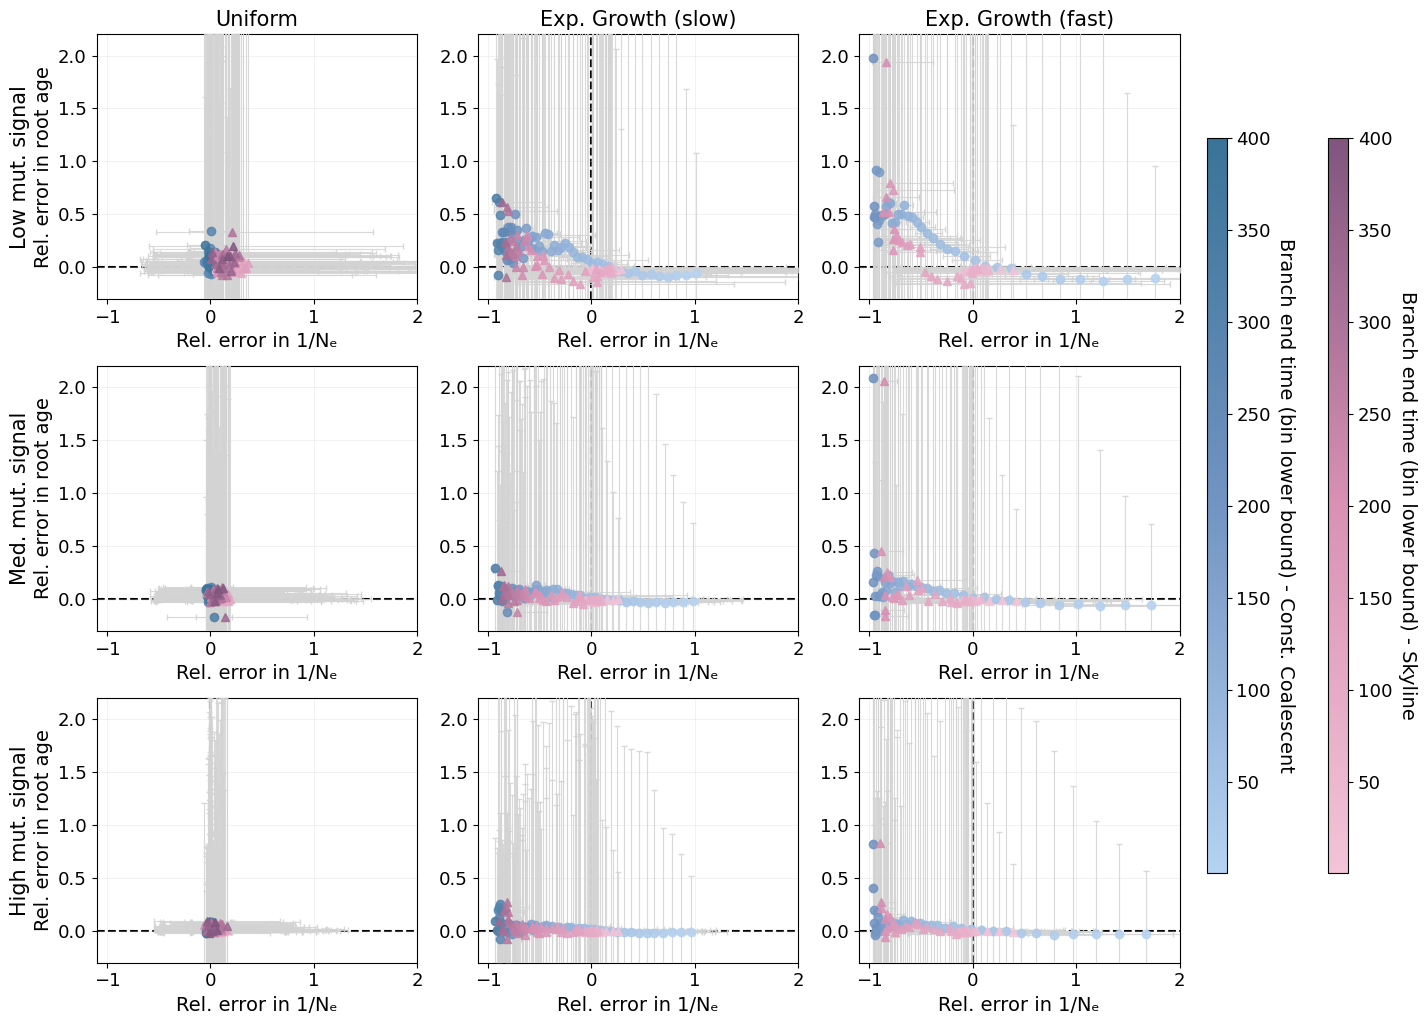

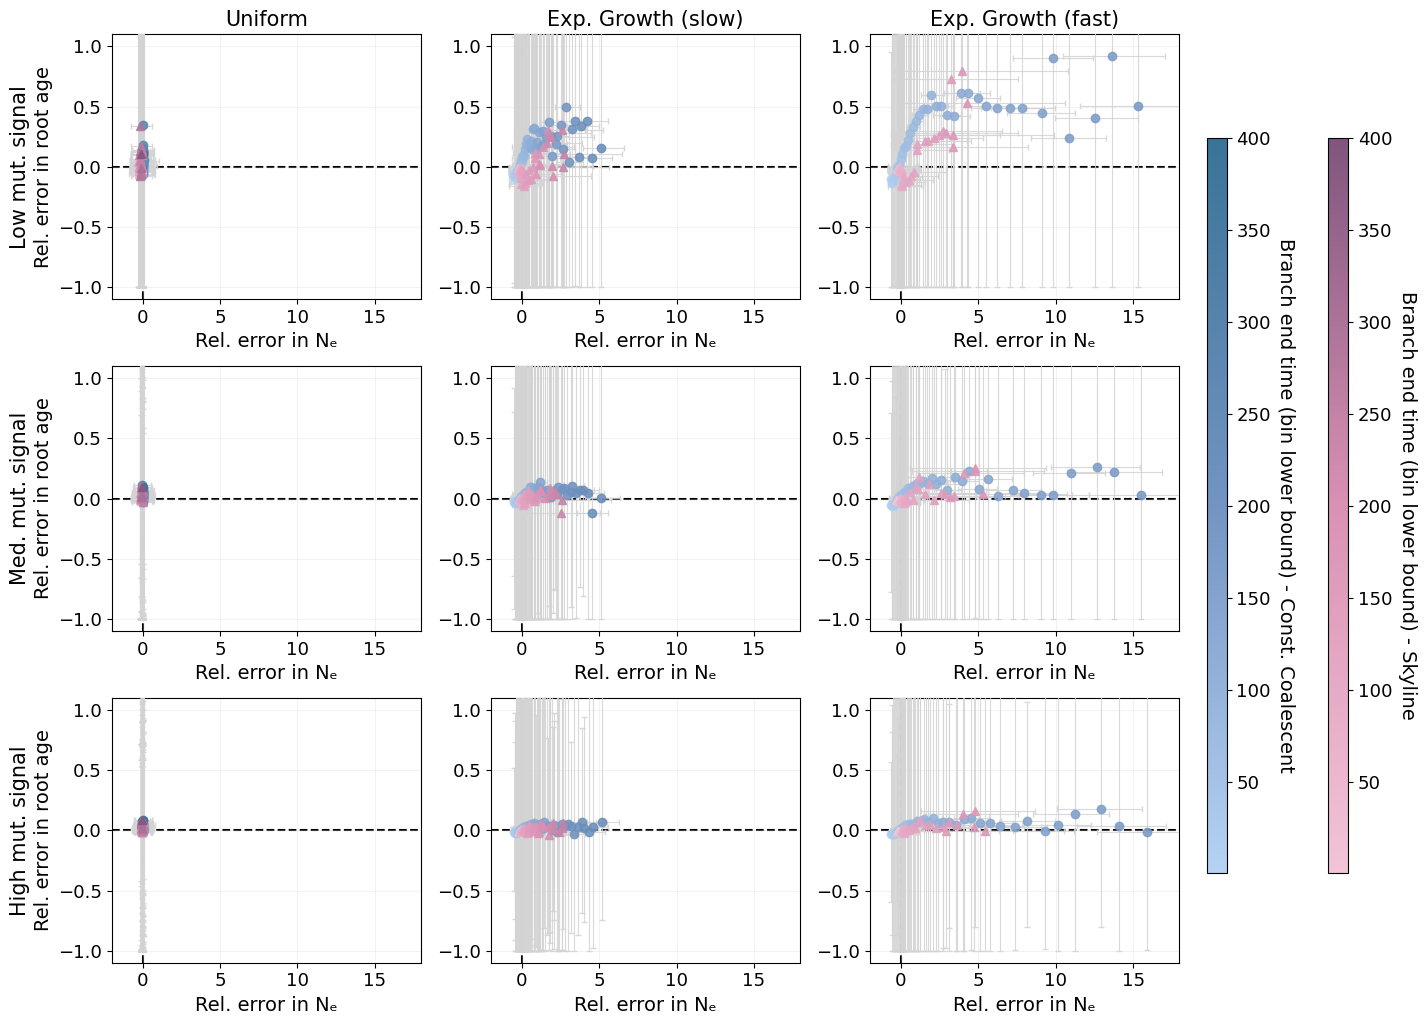

In [8]:
# linearconstant

## bin length 5, last bin at 100
### rate (rel error)
plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(-0.6, 0.6),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant.pdf")

plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(-0.6, 0.6),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10,
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_all.pdf")

plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-1.1,2.5), y_range=(-1,38),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_fullrange.pdf")

### rate (abs. rel. error)
plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_abs_rel_error", time_col = 'bin_lower',
                               x_range=(-2.5,2.5), y_range=(0, 1),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Abs rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/abs_bl_rate_error_linearconstant.pdf")

### pop. size (rel. error)
plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="pop_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-1.5,1.5), y_range=(-0.51,0.51),
                               x_label = "Rel. error in Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_popsize_error_linearconstant.pdf")

### pop.size (abs. rel. error)
plot_binned_error_timecoloring(df_5_100, sampling="linearconstant",
                               x_col="pop_rel_error", y_col="bl_abs_rel_error", time_col = 'bin_lower',
                               x_range=(-1.5,1.5), y_range=(0,1),
                               x_label = "Rel. error in Nₑ", y_label = "Abs. rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/abs_bl_popsize_error_linearconstant.pdf")


## bin length 5, last bin at 400
### rate
plot_binned_error_timecoloring(df_5_400, sampling="linearconstant",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-1.1,2), y_range=(-0.3,2.2),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_linearconstant_400.pdf")

### pop size
plot_binned_error_timecoloring(df_5_400, sampling="linearconstant",
                               x_col="pop_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2,18), y_range=(-1.1,1.1),
                               x_label = "Rel. error in Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=20, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_popsize_error_linearconstant_400.pdf")


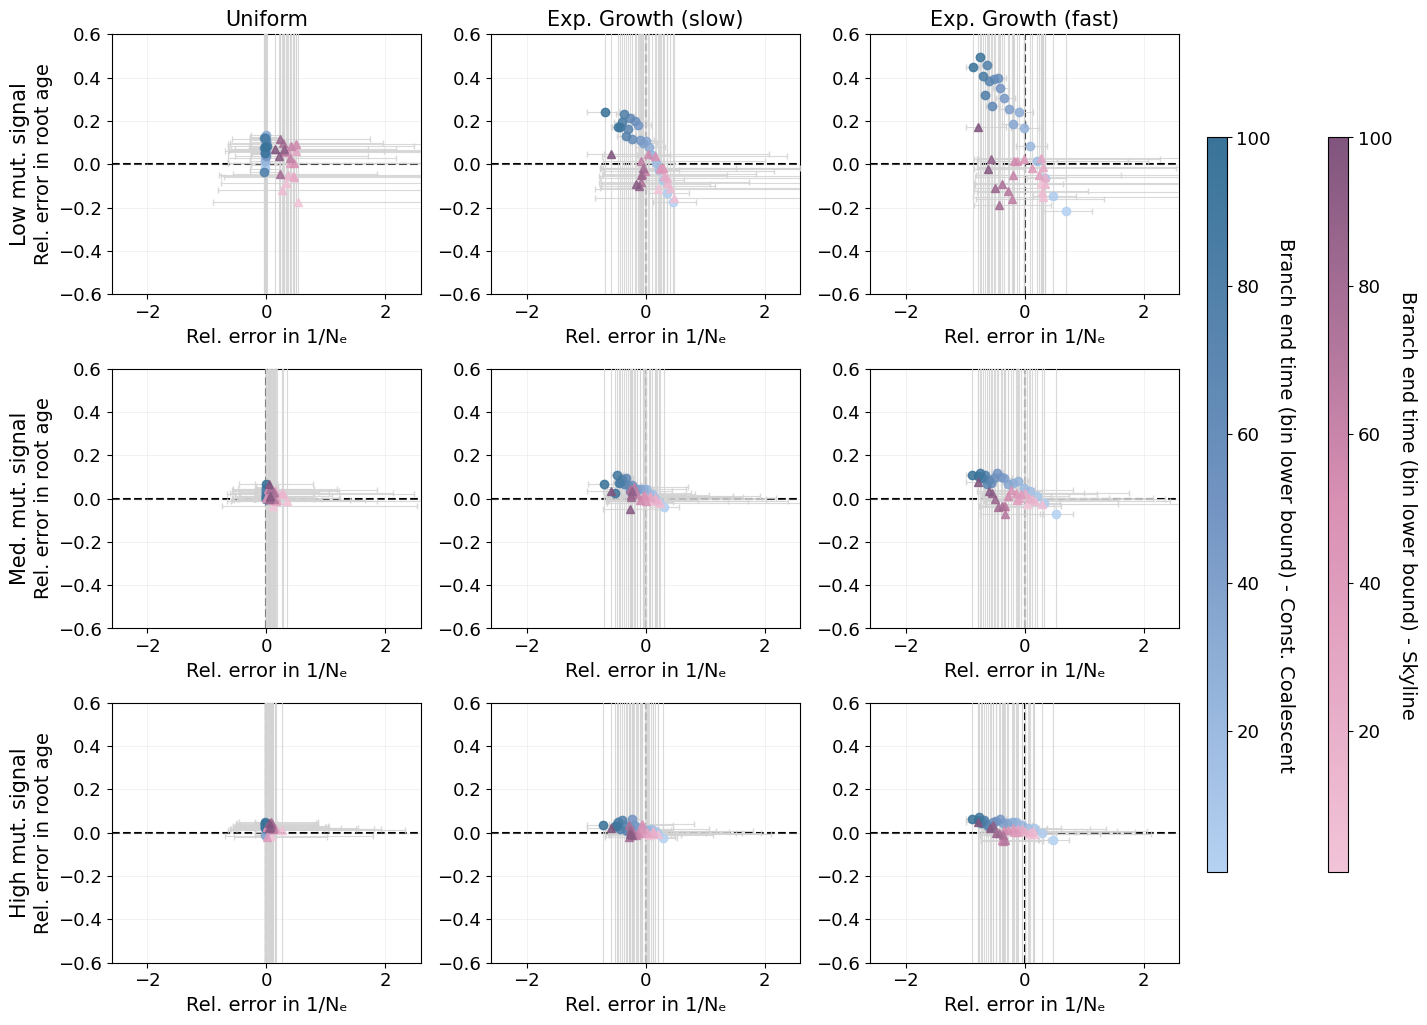

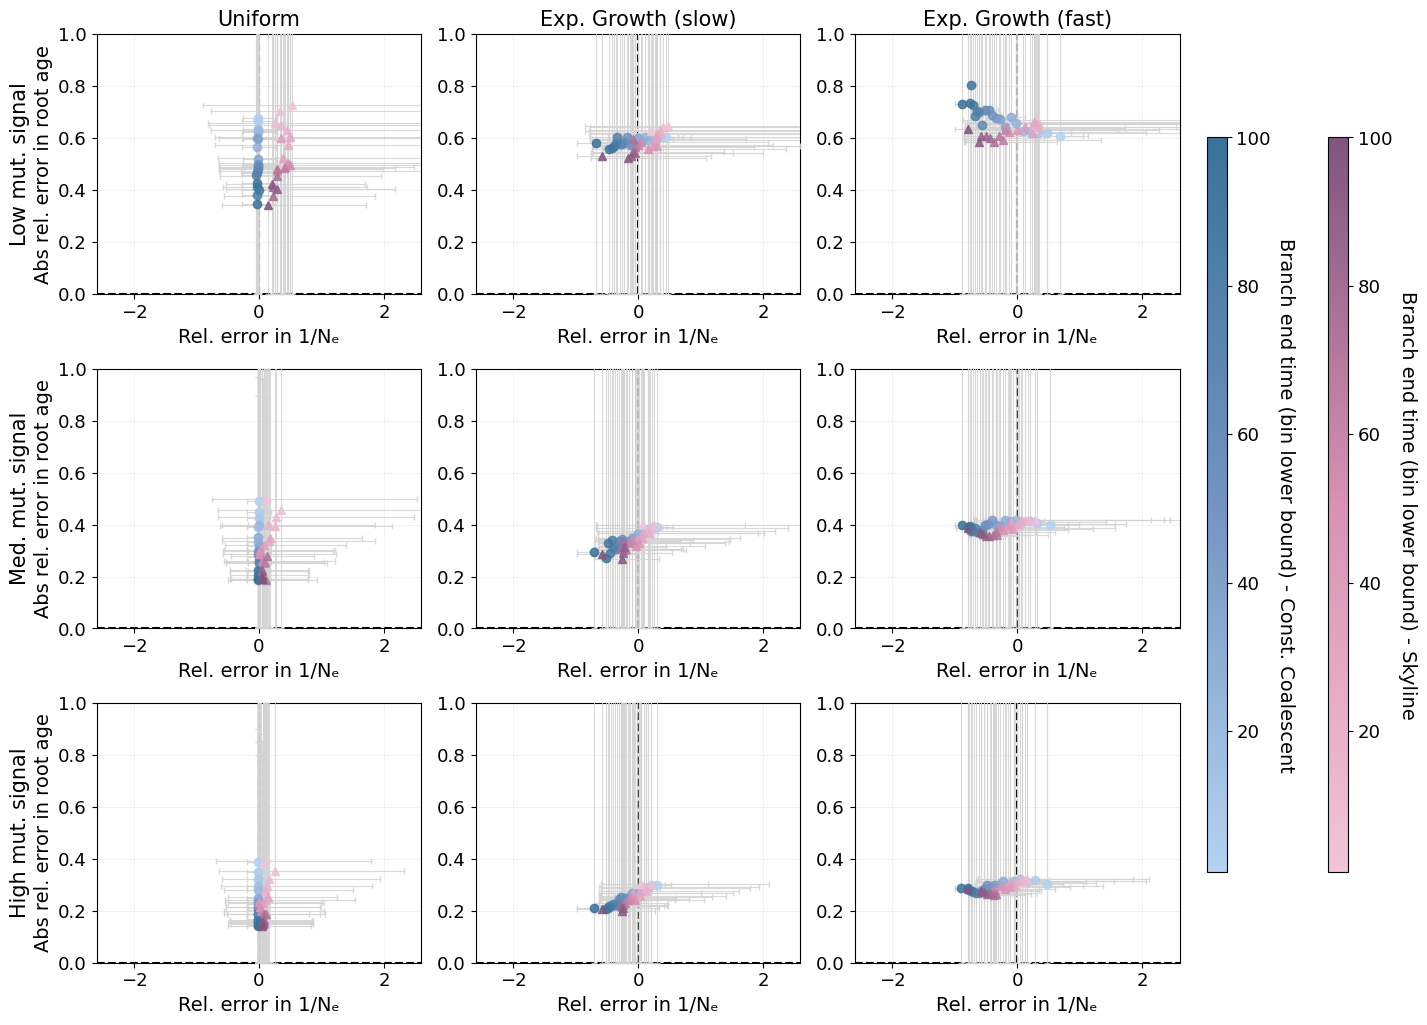

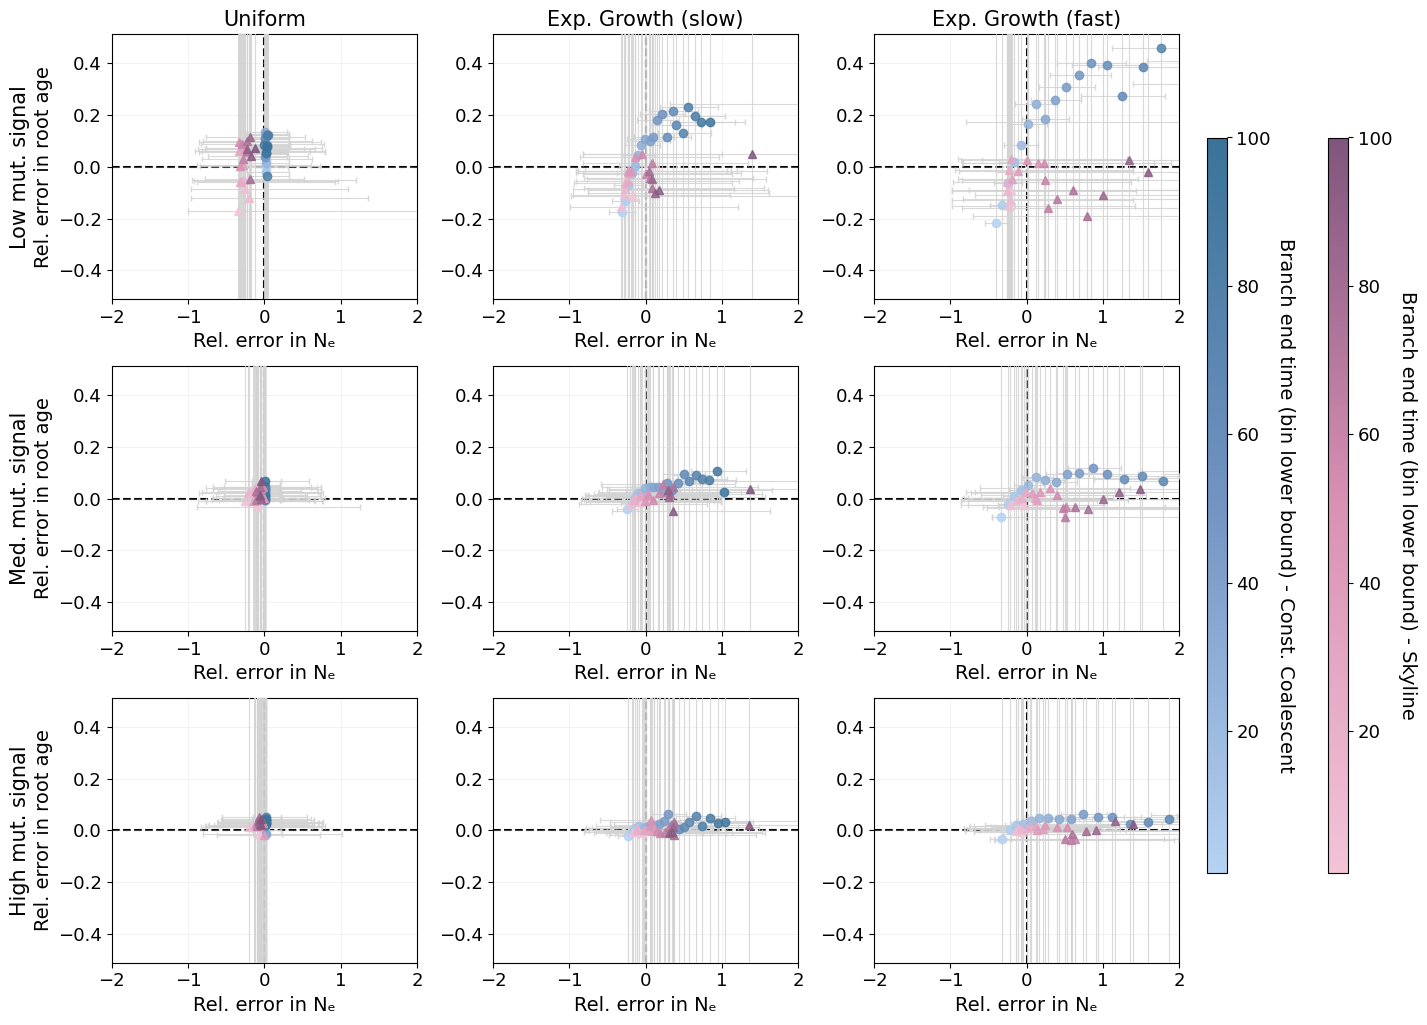

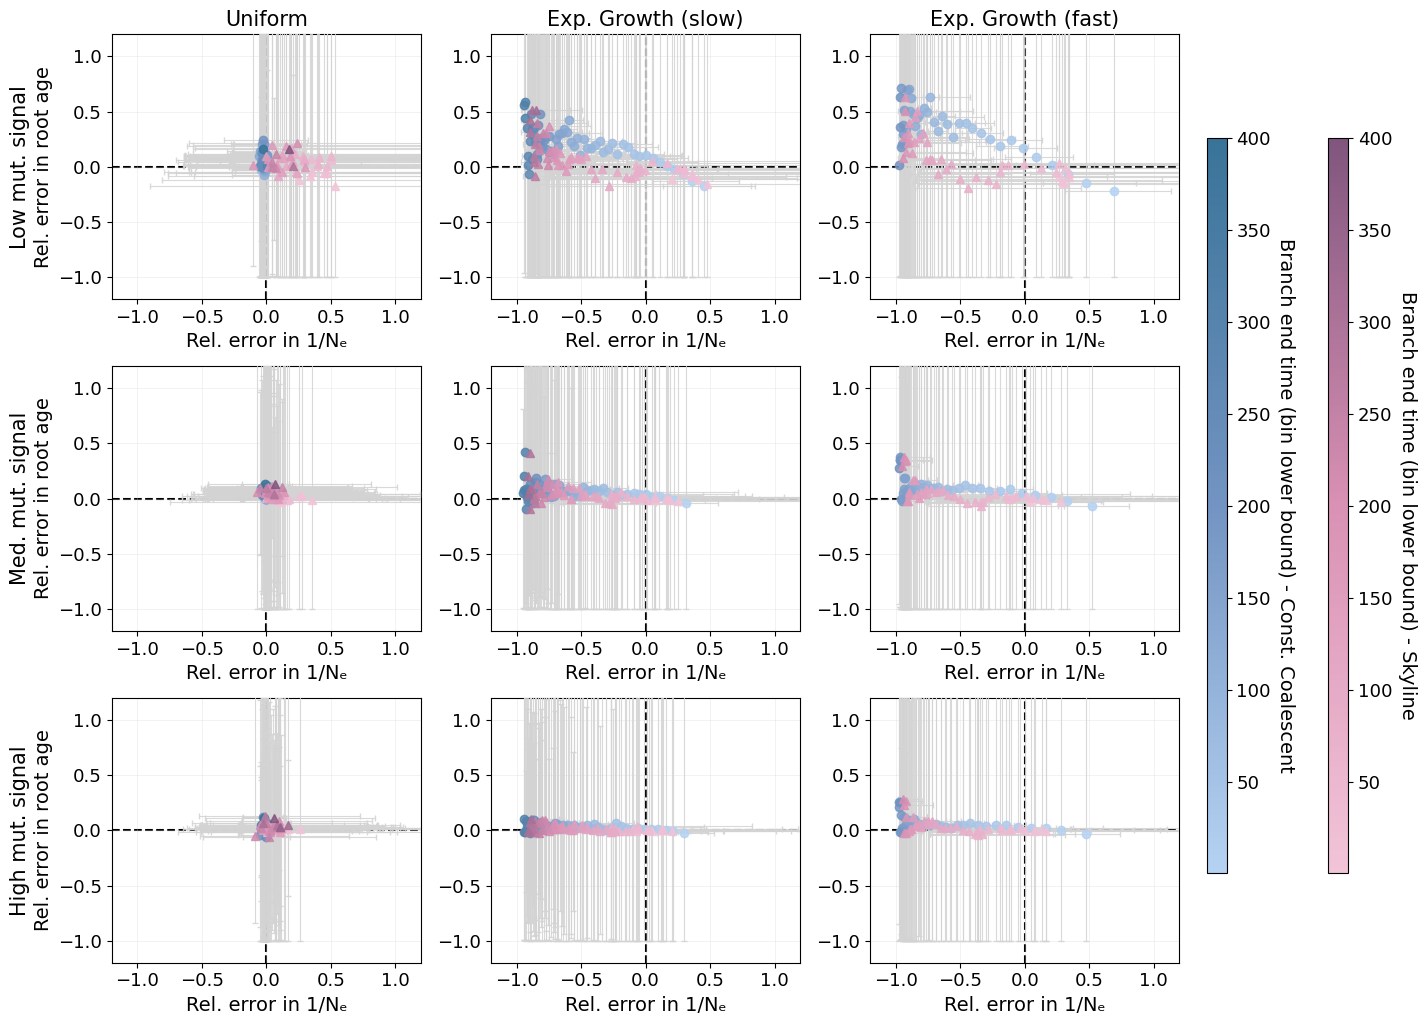

In [9]:
# independenthomochronous

## bin length 5, last bin at 100
### rate (rel error)
plot_binned_error_timecoloring(df_5_100, sampling="independenthomochronous",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2.6,2.6), y_range=(-0.6, 0.6),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_independenthomochronous.pdf")

### rate (abs. rel. error)
plot_binned_error_timecoloring(df_5_100, sampling="independenthomochronous",
                               x_col="rate_rel_error", y_col="bl_abs_rel_error", time_col = 'bin_lower',
                               x_range=(-2.6,2.6), y_range=(0, 1),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Abs rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/abs_bl_rate_error_independenthomochronous.pdf")

### pop. size (rel. error)
plot_binned_error_timecoloring(df_5_100, sampling="independenthomochronous",
                               x_col="pop_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-2,2), y_range=(-0.51,0.51),
                               x_label = "Rel. error in Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_popsize_error_independenthomochronous.pdf")

## bin length 5, last bin at 400
### rate
plot_binned_error_timecoloring(df_5_400, sampling="independenthomochronous",
                               x_col="rate_rel_error", y_col="bl_rel_error", time_col = 'bin_lower',
                               x_range=(-1.2,1.2), y_range=(-1.2,1.2),
                               x_label = "Rel. error in 1/Nₑ", y_label = "Rel. error in root age", title = "",
                               cbar_label_constcoal= "Branch end time (bin lower bound) - Const. Coalescent", cbar_label_skyline="Branch end time (bin lower bound) - Skyline",
                               min_nodes_per_bin=10, pop_models=['uniform', 'expgrowthslow', 'expgrowthfast'],
                               save_path="../figures/branch_length/time_popsize_scatter/bl_rate_error_independenthomochronous_400.pdf")
